# COSC2753 Assignment 2 - Fashion Intelligence System
### Task 4 - Fashion Visual Search
### Objective: Develop a model that retrieves visually similar fashion items
Tin Nguyen Trong - s4064843

Prerequisite: run `COSC2753_A2_Preprocessing.ipynb` first. This notebook loads the artifacts it writes to
`../data/processed/` instead of repeating the cleaning, splitting and encoding, so all four notebooks
mean the same thing by "validation".

## Part I - Load the preprocessed data

In [1]:
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from PIL import Image
from torch.utils.data import Dataset, WeightedRandomSampler
from torchvision import transforms as T
from sklearn.preprocessing import LabelEncoder

DATA_DIR = Path("../data/raw/FashionDataset")
OUT_DIR = Path("../data/processed")

TRAIN_CSV = DATA_DIR / "train" / "styles_train.csv"
IMAGES_TRAIN_DIR = DATA_DIR / "train" / "images_train"
TEST_PRED_CSV = DATA_DIR / "test" / "styles_prediction.csv"
IMAGES_TEST_DIR = DATA_DIR / "test" / "images_test"

REQUIRED = {
    "config":       OUT_DIR / "pipeline_config.json",
    "encoders":     OUT_DIR / "label_encoders.pkl",
    "train_full":   OUT_DIR / "train_full.csv",
    "val_full":     OUT_DIR / "val_full.csv",
    "holdout_dir":  OUT_DIR / "holdout_metadata",
}
missing = {k: v for k, v in REQUIRED.items() if not v.exists()}
for name, path in REQUIRED.items():
    print(f"[{'OK' if path.exists() else 'MISSING':>7}] {name:12s} {path}")
if missing:
    raise FileNotFoundError(
        "Run COSC2753_A2_Preprocessing.ipynb first -- it writes the files above. "
        f"Missing: {list(missing)}")

for p in [TRAIN_CSV, IMAGES_TRAIN_DIR, TEST_PRED_CSV, IMAGES_TEST_DIR]:
    print(f"[{'OK' if p.exists() else 'MISSING':>7}] {p}")

with open(REQUIRED["config"]) as f:
    config = json.load(f)

RANDOM_STATE = config["random_state"]
IMG_WIDTH = config["image"]["width"]
IMG_HEIGHT = config["image"]["height"]
mean = torch.tensor(config["image"]["normalization_mean"])
std = torch.tensor(config["image"]["normalization_std"])
ARTICLE_TYPE_MIN_COUNT = config["rare_class_thresholds"]["articleType"]
USAGE_MIN_COUNT = config["rare_class_thresholds"]["usage"]

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

print(f"\nSeed {RANDOM_STATE} | images {IMG_HEIGHT}x{IMG_WIDTH} (HxW)")
print(f"Normalisation mean {[round(v, 4) for v in mean.tolist()]}, "
      f"std {[round(v, 4) for v in std.tolist()]}")
print(f"Rare-class thresholds: articleType>={ARTICLE_TYPE_MIN_COUNT}, usage>={USAGE_MIN_COUNT}")

[     OK] config       ../data/processed/pipeline_config.json
[     OK] encoders     ../data/processed/label_encoders.pkl
[     OK] train_full   ../data/processed/train_full.csv
[     OK] val_full     ../data/processed/val_full.csv
[     OK] holdout_dir  ../data/processed/holdout_metadata
[     OK] ../data/raw/FashionDataset/train/styles_train.csv
[     OK] ../data/raw/FashionDataset/train/images_train
[     OK] ../data/raw/FashionDataset/test/styles_prediction.csv
[     OK] ../data/raw/FashionDataset/test/images_test

Seed 42 | images 80x60 (HxW)
Normalisation mean [0.8476, 0.8307, 0.8243], std [0.274, 0.285, 0.2889]
Rare-class thresholds: articleType>=20, usage>=100


In [ ]:
# dtype={'id': str} is load-bearing
ID_DTYPE = {"id": str}

train_data = pd.read_csv(OUT_DIR / "train_full.csv", dtype=ID_DTYPE)
val_data = pd.read_csv(OUT_DIR / "val_full.csv", dtype=ID_DTYPE)

with open(OUT_DIR / "label_encoders.pkl", "rb") as f:
    encoders = pickle.load(f)

holdout_dir = OUT_DIR / "holdout_metadata"
train_usable, val_usable = {}, {}
for t in encoders:
    train_usable[t] = pd.read_csv(holdout_dir / f"{t}_train.csv", dtype=ID_DTYPE)
    val_usable[t] = pd.read_csv(holdout_dir / f"{t}_val.csv", dtype=ID_DTYPE)

# `target_columns` maps a task name to the column actually predicted, which is NOT always
# the task name: rare-class grouping means articleType -> articleType_grouped and
# usage -> usage_grouped. Rebuilt by inspecting the saved files rather than hardcoded, so
# it cannot drift out of step with what preprocessing produced.
target_columns = {}
for t in encoders:
    candidates = [f"{t}_grouped", t]
    col = next((c for c in candidates
                if c in train_usable[t].columns and f"{c}_enc" in train_usable[t].columns), None)
    if col is None:
        raise KeyError(
            f"{t}: no encoded target column found. Looked for "
            f"{[c + '_enc' for c in candidates]} in {holdout_dir / f'{t}_train.csv'}. "
            "Re-run the preprocessing notebook to regenerate the holdout files.")
    target_columns[t] = col

# The main split partitions the cleaned dataset exactly, so `df` is recoverable by
# concatenation. Task 2's season split is a separate draw from the same rows (Section
# II.4.1) and is already reflected in the season_* holdout files, so it needs nothing here.
df = pd.concat([train_data, val_data], ignore_index=True)

print(f"train_full: {train_data.shape}   val_full: {val_data.shape}   combined: {df.shape}")
print("\nPer-task usable subsets:")
for t, col in target_columns.items():
    print(f"  {t:12s} -> column {col:20s} train={len(train_usable[t]):>6}  "
          f"val={len(val_usable[t]):>6}  classes={len(encoders[t].classes_):>3}")

# --- integrity checks: the saved split must still be a valid split -----------
assert set(train_data["id"]).isdisjoint(set(val_data["id"])), "id overlap between train and val"
assert set(train_data["dup_group"]).isdisjoint(set(val_data["dup_group"])), \
    "duplicate-image group spans the split"
assert df["id"].is_unique, "duplicate ids in the reloaded data"
for t, col in target_columns.items():
    enc_col = f"{col}_enc"
    n_cls = len(encoders[t].classes_)
    for name, frame in (("train", train_usable[t]), ("val", val_usable[t])):
        assert frame[col].notna().all(), f"{t}: null target in {name}"
        assert frame[enc_col].notna().all(), f"{t}: missing encoded label in {name}"
        assert frame[enc_col].between(0, n_cls - 1).all(), f"{t}: encoded label out of range in {name}"
        assert set(frame[col]).issubset(set(encoders[t].classes_)), \
            f"{t}: {name} contains a class the encoder never saw"
        # The encoded column must actually agree with the encoder, not merely be in range --
        # a stale CSV paired with a newer pickle would pass every check above.
        assert (encoders[t].transform(frame[col]) == frame[enc_col].to_numpy()).all(), \
            f"{t}: {enc_col} disagrees with label_encoders.pkl -- re-run preprocessing"
print("\nIntegrity checks passed: split is disjoint, ids unique, labels in range.")

train_full: (28371, 13)   val_full: (9457, 13)   combined: (37828, 13)

Per-task usable subsets:
  articleType  -> column articleType_grouped  train= 28371  val=  9455  classes= 95
  season       -> column season               train= 28357  val=  9451  classes=  4
  gender       -> column gender               train= 28371  val=  9457  classes=  5
  usage        -> column usage_grouped        train= 28315  val=  9442  classes=  5

Integrity checks passed: split is disjoint, ids unique, labels in range.


In [3]:
def to_rgb(img):
    """Converts the 249 grayscale ('L' mode) files to 3-channel. A module-level function,
    not a lambda, so the transform stays picklable for DataLoader(num_workers>0)."""
    return img.convert("RGB")


# Evaluation pipeline: no augmentation, so it stays a faithful evaluation signal.
eval_transform = T.Compose([
    to_rgb,
    T.Resize((IMG_HEIGHT, IMG_WIDTH)),
    T.ToTensor(),
    T.Normalize(mean=mean.tolist(), std=std.tolist()),
])

# Training pipeline: conservative augmentation only. These are catalog product photos, so a
# vertical flip or a large rotation would produce an item that never occurs in the data.
# fill=255 because the backgrounds are white -- the default fill=0 would paste black wedges
# into every rotated corner and teach the model an artefact absent at evaluation time.
train_transform = T.Compose([
    to_rgb,
    T.Resize((IMG_HEIGHT, IMG_WIDTH)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10, fill=255),
    T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
    T.ToTensor(),
    T.Normalize(mean=mean.tolist(), std=std.tolist()),
])


class FashionImageDataset(Dataset):
    """(image, label) pairs. `target_col` names an already-encoded integer column."""

    def __init__(self, dataframe, images_dir, target_col, transform):
        self.data = dataframe.reset_index(drop=True)
        self.images_dir = Path(images_dir)
        self.target_col = target_col
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        with Image.open(self.images_dir / f"{row['id']}.jpg") as im:
            img = self.transform(im)
        return img, int(row[self.target_col])


def get_weighted_sampler(data, target_col):
    """Inverse-frequency WeightedRandomSampler. Train split only -- never apply to
    validation, which must keep the real class distribution to stay a fair estimate."""
    counts = data[target_col].value_counts()
    weights = torch.tensor(
        data[target_col].map(lambda c: 1.0 / counts[c]).to_numpy(dtype="float64"),
        dtype=torch.double
    )
    return WeightedRandomSampler(weights=weights, num_samples=len(weights), replacement=True)


# Class weights, computed for reference. Imbalance is handled by the sampler above, not by
# weighting the loss -- applying both would double-count the correction.
class_weights = {}
for t, col in target_columns.items():
    vc = train_usable[t][col].value_counts()
    n_samples, n_classes = len(train_usable[t]), len(encoders[t].classes_)
    w = n_samples / (n_classes * vc)
    class_weights[t] = torch.tensor([w[c] for c in encoders[t].classes_], dtype=torch.float32)

# Verify the reconstructed pipeline against a real image before anything depends on it.
_probe_id = train_data["id"].iloc[0]
_probe = eval_transform(Image.open(IMAGES_TRAIN_DIR / f"{_probe_id}.jpg"))
assert _probe.shape == (3, IMG_HEIGHT, IMG_WIDTH), f"unexpected tensor shape {tuple(_probe.shape)}"
print(f"Transform check: image {_probe_id} -> tensor {tuple(_probe.shape)}, "
      f"range [{_probe.min():.2f}, {_probe.max():.2f}]")
print("Ready: train_data, val_data, df, train_usable, val_usable, encoders,")
print("       train_transform, eval_transform, FashionImageDataset, get_weighted_sampler")

Transform check: image 1163 -> tensor (3, 80, 60), range [-3.05, 0.61]
Ready: train_data, val_data, df, train_usable, val_usable, encoders,
       train_transform, eval_transform, FashionImageDataset, get_weighted_sampler


## Part II - Task 4

## Task 4: Fashion visual search

The task: **Given a query fashion image, which items in the collection look most similar to it?** 

This is not a classification problem, since there is no fixed set of labels to predict. The system ranks the 28,371
gallery images by visual similarity and returns the Top-K. The model outputs an embedding, it is trained with a distance-based loss, and it is scored with ranking metrics.

In [4]:
# Task 4 additions to the preamble's imports. The shared preprocessing section
# above imports what IT needs; these are what the retrieval work below needs.
import copy
import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader, Sampler
from torchvision.models import resnet18
from tqdm.auto import tqdm


def get_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    if torch.backends.mps.is_available():          # Apple Silicon
        return torch.device('mps')
    return torch.device('cpu')


DEVICE = get_device()      # used from Step 5 onward
EMB_DIM = 128              # every approach embeds to the same dimension, so the
                           # comparison isolates the training objective, not capacity
print(f"Task 4 imports ready. Device: {DEVICE}, embedding dim: {EMB_DIM}")

Task 4 imports ready. Device: mps, embedding dim: 128


### Which split Task 4 evaluates on

Task 4 scores against the team's shared split loaded in Part I, so the gallery and query sets are the
train and validation sides of `data/processed`.

| | |
|---|---|
| Gallery | 28,371 images, the train split |
| Queries | 9,455 images, the validation split |
| Classes | 95 `articleType_grouped` |

Every model here, and every rung of the ladder in Step 11b, is trained on this split and scored on
it. `experiments/rung_ablation.py` writes a hash of the gallery and query membership into every
result file, and Step 11b confirms all nine rungs match.

## Step 1 - Framing: gallery vs. query

The gallery is the searchable collection and a query is answered by ranking it. A query image that
also sits in the gallery retrieves itself at rank 1 with a perfect score, which inflates every
metric. The gallery is therefore the train split of 28,371 images and the queries the validation
split of 9,455, which the shared split guarantees are disjoint on both `id` and `dup_group`.

The deployed index in Step 16 withholds nothing, so all 37,826 labelled images go in. Only the
held-out index produces a number.

In [5]:
# Gallery = train split (indexed, searchable). Queries = val split (held out, never indexed).
# Taken from train_usable/val_usable['articleType'] rather than train_data/val_data: those are
# the Task-1-aligned frames that already carry `articleType_grouped_enc` (built by Part I),
# which both the classifier baseline and the PK sampler need.
gallery_df = train_usable['articleType'].reset_index(drop=True).copy()
query_df   = val_usable['articleType'].reset_index(drop=True).copy()

print(f"Gallery: {len(gallery_df):,} images")
print(f"Queries: {len(query_df):,} images")

for col in ['articleType_grouped', 'articleType_grouped_enc', 'baseColour']:
    assert col in gallery_df.columns and col in query_df.columns, f"missing column: {col}"

# The two leakage guarantees this task depends on -- assert them rather than trust them.
assert set(gallery_df['id']).isdisjoint(set(query_df['id'])), "query id found in gallery"
assert set(gallery_df['dup_group']).isdisjoint(set(query_df['dup_group'])), \
    "a duplicate of a query image is sitting in the gallery"
print("No id overlap and no duplicate-image-group overlap between gallery and queries -- OK")

print(f"\nDistinct articleType_grouped in gallery: {gallery_df['articleType_grouped'].nunique()}")
print(f"Distinct baseColour in gallery: {gallery_df['baseColour'].nunique()}")

Gallery: 28,371 images
Queries: 9,455 images
No id overlap and no duplicate-image-group overlap between gallery and queries -- OK

Distinct articleType_grouped in gallery: 95
Distinct baseColour in gallery: 47


## Step 2 - Preprocessing changes this task needs

Two of the shared pipeline's choices do not suit retrieval.

**Images are decoded once into memory.** The whole gallery is re-embedded after every epoch, so
per-request JPEG decoding costs more than the training step it measures. All 37,826 images are
decoded once, resized to 60x80 and held in a uint8 array of about 545 MB. The check below confirms a
cached and an uncached run produce identical tensors.

**A class-balanced PK sampler replaces `WeightedRandomSampler`.** Triplet loss needs a same-class
positive in the batch, and sampling independently across 95 classes into a batch of 64 leaves most
anchors with none. Each batch is built from P=16 classes with K=4 images, giving every anchor 3
positives and 60 negatives. Classes with one image are dropped from the training sampler only.

In [6]:
import torch.nn.functional as F
from torch.utils.data import Sampler

# ── Change 1: decode-once image cache ────────────────────────────────────────
def build_image_cache(ids, folder, size_hw=(IMG_HEIGHT, IMG_WIDTH)):
    """Decode each image once into a uint8 array. Same resize target as Part I,
    so the tensors the model sees are unchanged -- only the decode cost moves."""
    h, w = size_hw
    cache = np.zeros((len(ids), h, w, 3), dtype=np.uint8)
    index = {}
    for i, img_id in enumerate(tqdm(list(ids), desc="caching images")):
        with Image.open(folder / f"{img_id}.jpg") as im:
            im = im.convert("RGB").resize((w, h))
            cache[i] = np.asarray(im, dtype=np.uint8)
        index[str(img_id)] = i
    return cache, index


class CachedFashionImageDataset(Dataset):
    """Drop-in replacement for FashionImageDataset that serves from the in-memory
    cache. Applies the SAME transform objects built in Part I."""

    def __init__(self, dataframe, cache, index, transform, label_col=None):
        self.df = dataframe.reset_index(drop=True)
        self.cache, self.index, self.transform = cache, index, transform
        self.label_col = label_col
        self.rows = np.array([self.index[str(i)] for i in self.df['id']])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img = Image.fromarray(self.cache[self.rows[idx]])
        img = self.transform(img)
        if self.label_col is None:
            return img, torch.tensor(0, dtype=torch.long)
        return img, torch.tensor(int(self.df.iloc[idx][self.label_col]), dtype=torch.long)


train_cache, train_index = build_image_cache(
    pd.concat([gallery_df['id'], query_df['id']]).unique(), IMAGES_TRAIN_DIR)
print(f"\nCached {train_cache.shape[0]:,} images -> array {train_cache.shape}, "
      f"{train_cache.nbytes / 1e6:.0f} MB")

caching images:   0%|          | 0/37826 [00:00<?, ?it/s]


Cached 37,826 images -> array (37826, 80, 60, 3), 545 MB


In [7]:
# Verify the cache is faithful: a cached sample must equal the on-disk pipeline exactly.
_check = gallery_df.sample(5, random_state=RANDOM_STATE)
_cached_ds = CachedFashionImageDataset(_check, train_cache, train_index, eval_transform)
_disk_ds = FashionImageDataset(
    _check.assign(_lbl=0), IMAGES_TRAIN_DIR, '_lbl', eval_transform)

max_diff = max(float((_cached_ds[i][0] - _disk_ds[i][0]).abs().max()) for i in range(len(_check)))
print(f"Max abs difference between cached and on-disk tensors: {max_diff:.2e}")
assert max_diff < 1e-5, "cache is not faithful to the on-disk pipeline"
print("Cache verified identical to the shared on-disk pipeline -- OK")

Max abs difference between cached and on-disk tensors: 0.00e+00
Cache verified identical to the shared on-disk pipeline -- OK


In [8]:
# ── Change 2: class-balanced PK sampler ──────────────────────────────────────
class PKSampler(Sampler):
    """Yields batches of P classes x K images. Guarantees every anchor has K-1
    positives and (P-1)*K negatives in its own batch -- the precondition for
    batch-hard triplet mining (Step 10)."""

    def __init__(self, labels, P=16, K=4, batches_per_epoch=400, seed=RANDOM_STATE):
        self.labels = np.asarray(labels)
        self.P, self.K, self.batches_per_epoch = P, K, batches_per_epoch
        self.rng = np.random.default_rng(seed)
        self.class_to_idx = {c: np.flatnonzero(self.labels == c)
                             for c in np.unique(self.labels)}
        # A single-image class can never supply a positive pair -> unusable for training.
        self.usable = [c for c, idx in self.class_to_idx.items() if len(idx) >= 2]

    def __iter__(self):
        for _ in range(self.batches_per_epoch):
            chosen = self.rng.choice(self.usable, size=min(self.P, len(self.usable)), replace=False)
            batch = []
            for c in chosen:
                pool = self.class_to_idx[c]
                # replace=True only when a class has fewer than K images
                batch.extend(self.rng.choice(pool, size=self.K, replace=len(pool) < self.K))
            yield [int(i) for i in batch]

    def __len__(self):
        return self.batches_per_epoch


P_CLASSES, K_PER_CLASS = 16, 4
METRIC_BATCH = P_CLASSES * K_PER_CLASS

_labels = gallery_df['articleType_grouped'].values
_sampler_probe = PKSampler(_labels, P=P_CLASSES, K=K_PER_CLASS)
n_dropped = len(np.unique(_labels)) - len(_sampler_probe.usable)
print(f"Classes in gallery: {len(np.unique(_labels))}")
print(f"Usable for triplet training (>=2 images): {len(_sampler_probe.usable)}")
print(f"Excluded from the TRAINING SAMPLER ONLY (still in gallery, still scored): {n_dropped}")
print(f"Batch shape: P={P_CLASSES} classes x K={K_PER_CLASS} images = {METRIC_BATCH} per batch")

Classes in gallery: 95
Usable for triplet training (>=2 images): 93
Excluded from the TRAINING SAMPLER ONLY (still in gallery, still scored): 2
Batch shape: P=16 classes x K=4 images = 64 per batch


## Step 3 - Defining "relevant", since retrieval has no ground truth

Nobody labelled which gallery images look similar to a given query, so metadata is used as a proxy
under two definitions.

| Definition | A retrieved item is relevant if | How it is wrong |
|---|---|---|
| Simple | its `articleType_grouped` matches the query's | a black shoe and a pink shoe both count as perfect hits |
| Strict | `articleType_grouped` and `baseColour` both match | it over-punishes a similar item in a near-identical shade |

Both are reported. Simple relevance can be satisfied by Task 1's classification boundary alone;
strict relevance also requires the embedding to keep colour. Since this is a proxy, a "Casual Shoes"
result for a "Sports Shoes" query counts as a miss even when a shopper would find it useful, so every
number below compares models against each other rather than measuring search quality absolutely.

In [9]:
# Relevance is precomputed as integer codes so scoring is a fast array comparison
# rather than string matching inside the ranking loop.
_at_codes = {c: i for i, c in enumerate(
    pd.concat([gallery_df['articleType_grouped'], query_df['articleType_grouped']]).astype(str).unique())}
_bc_codes = {c: i for i, c in enumerate(
    pd.concat([gallery_df['baseColour'], query_df['baseColour']]).astype(str).unique())}

def relevance_codes(frame):
    at = frame['articleType_grouped'].astype(str).map(_at_codes).to_numpy()
    bc = frame['baseColour'].astype(str).map(_bc_codes).to_numpy()
    return at, bc

gal_at, gal_bc = relevance_codes(gallery_df)
qry_at, qry_bc = relevance_codes(query_df)

print(f"articleType codes: {len(_at_codes)}   baseColour codes: {len(_bc_codes)}")
print(f"gallery arrays: {gal_at.shape}, query arrays: {qry_at.shape}")

# Prevalence of each definition = the score a random ranker is expected to achieve.
rand_simple = float(np.mean([(gal_at == a).mean() for a in qry_at[:2000]]))
rand_strict = float(np.mean([((gal_at == a) & (gal_bc == b)).mean()
                             for a, b in zip(qry_at[:2000], qry_bc[:2000])]))
print(f"\nRandom-ranker expected precision (simple): {rand_simple:.4f}")
print(f"Random-ranker expected precision (strict): {rand_strict:.4f}")

articleType codes: 95   baseColour codes: 47
gallery arrays: (28371,), query arrays: (9455,)

Random-ranker expected precision (simple): 0.0912
Random-ranker expected precision (strict): 0.0117


## Step 4 - Ranking metrics

Retrieval is judged on the quality of a ranked list.

- Precision@K: of the K items returned, what fraction are relevant. Primary metric.
- mAP@K: like Precision@K, but also rewards putting relevant items higher. Primary.
- Hit-rate@K: did at least one relevant item appear in the top K.

Recall is reported at K=100 but not used to choose between models: with thousands of T-shirts in the
gallery a perfect 10-result page reaches about 0.2% recall, so it tracks class frequency more than
model quality. K=10 is the headline, with K=1, 5 and 20 alongside.

In [10]:
K_VALUES = [1, 5, 10, 20]
K_PRIMARY = 10

# Total relevant items per query are needed to normalise AP@k. Computing them as a
# full (n_queries x n_gallery) boolean matrix would allocate ~280 MB per call, so they
# are precomputed once as count lookups instead.
_gal_at_counts = np.bincount(gal_at, minlength=len(_at_codes))
_pair_key_gal = gal_at.astype(np.int64) * (len(_bc_codes) + 1) + gal_bc
_pair_counts = {}
for k_, v_ in zip(*np.unique(_pair_key_gal, return_counts=True)):
    _pair_counts[int(k_)] = int(v_)


def _n_relevant(q_at_arr, q_bc_arr, strict):
    if not strict:
        return _gal_at_counts[q_at_arr]
    keys = q_at_arr.astype(np.int64) * (len(_bc_codes) + 1) + q_bc_arr
    return np.array([_pair_counts.get(int(k_), 0) for k_ in keys])


def retrieval_metrics(topk_idx, q_at, q_bc, g_at, g_bc, k_values=K_VALUES, strict=False):
    """Score a ranked retrieval result.

    topk_idx : (n_queries, max_k) gallery indices, already sorted best-first.
    Returns per-query arrays so bootstrap CIs can resample queries directly.
    """
    rel = (g_at[topk_idx] == q_at[:, None])
    if strict:
        rel &= (g_bc[topk_idx] == q_bc[:, None])

    n_rel_total = _n_relevant(q_at, q_bc, strict)
    out = {}
    for k in k_values:
        rel_k = rel[:, :k]
        out[f'P@{k}'] = rel_k.mean(axis=1)
        out[f'Hit@{k}'] = rel_k.any(axis=1).astype(float)
        # Average Precision @ k: mean of precision-at-each-hit, normalised by
        # min(k, total relevant) so a query with few relevant items isn't penalised.
        csum = np.cumsum(rel_k, axis=1)
        ranks = np.arange(1, k + 1)[None, :]
        prec_at_hits = (csum / ranks) * rel_k
        denom = np.minimum(k, np.maximum(n_rel_total, 1))
        out[f'AP@{k}'] = prec_at_hits.sum(axis=1) / denom
    return out


def summarise(name, topk_idx, verbose=True):
    """Both relevance definitions for one model, as a single tidy row."""
    simple = retrieval_metrics(topk_idx, qry_at, qry_bc, gal_at, gal_bc, strict=False)
    strict = retrieval_metrics(topk_idx, qry_at, qry_bc, gal_at, gal_bc, strict=True)
    row = {'model': name}
    for k in K_VALUES:
        row[f'P@{k}'] = simple[f'P@{k}'].mean()
        row[f'mAP@{k}'] = simple[f'AP@{k}'].mean()
    row['Hit@10'] = simple['Hit@10'].mean()
    row['P@10 (strict)'] = strict['P@10'].mean()
    row['mAP@10 (strict)'] = strict['AP@10'].mean()
    if verbose:
        print(f"{name:34s} P@10={row['P@10']:.4f}  mAP@10={row['mAP@10']:.4f}  "
              f"| strict P@10={row['P@10 (strict)']:.4f}  mAP@10={row['mAP@10 (strict)']:.4f}")
    return row, simple, strict


print(f"Metrics defined. Primary K = {K_PRIMARY}; also reporting K = {K_VALUES}.")

Metrics defined. Primary K = 10; also reporting K = [1, 5, 10, 20].


## Step 5 - Shared embedding and search infrastructure

Every approach reduces to the same three operations, written once here and reused, so the only thing
that varies between rows of the final table is how the embedding is produced.

Similarity is cosine similarity on L2-normalised vectors, which puts every embedding on the unit
sphere and turns the search into one matrix multiply. No approximate index is used: the gallery is
about 15 MB and the full similarity matrix computes in seconds.

In [11]:
@torch.no_grad()
def embed_with_model(encoder, frame, cache, index, batch_size=256, l2=True):
    """Run an encoder over a dataframe's images and return (n, d) embeddings.
    Always uses eval_transform -- augmentation would make the index non-deterministic."""
    encoder.eval()
    ds = CachedFashionImageDataset(frame, cache, index, eval_transform)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)
    out = []
    for imgs, _ in tqdm(loader, desc="embedding", leave=False):
        emb = encoder(imgs.to(DEVICE))
        out.append(emb.float().cpu())
    emb = torch.cat(out).numpy()
    return l2_normalise(emb) if l2 else emb


def l2_normalise(x):
    norms = np.linalg.norm(x, axis=1, keepdims=True)
    return x / np.maximum(norms, 1e-12)


def search_topk(query_emb, gallery_emb, k=max(K_VALUES), chunk=1024):
    """Exact cosine top-k. Chunked over queries to bound peak memory."""
    idx_out = np.empty((len(query_emb), k), dtype=np.int64)
    g = gallery_emb.T.astype(np.float32)
    for start in range(0, len(query_emb), chunk):
        stop = min(start + chunk, len(query_emb))
        sims = query_emb[start:stop].astype(np.float32) @ g
        part = np.argpartition(-sims, kth=k - 1, axis=1)[:, :k]
        order = np.argsort(-np.take_along_axis(sims, part, axis=1), axis=1)
        idx_out[start:stop] = np.take_along_axis(part, order, axis=1)
    return idx_out


def evaluate_embedding(name, gal_emb, qry_emb, verbose=True):
    topk = search_topk(qry_emb, gal_emb)
    return (*summarise(name, topk, verbose=verbose), topk)


print("Embedding, search and evaluation helpers ready.")
print(f"Device: {DEVICE}")

Embedding, search and evaluation helpers ready.
Device: mps


## Step 6 - Baseline A: raw downscaled pixels

No model and no training. Each image is shrunk to 15x20 and its 900 raw pixel values become the
embedding. The photos are clean, centred and shot on white backgrounds, so two images of the same
product really are close in pixel space. If a trained model cannot beat this, the training is not
earning its keep.

In [12]:
PIXEL_H, PIXEL_W = 20, 15

def pixel_embeddings(frame):
    rows = np.array([train_index[str(i)] for i in frame['id']])
    imgs = train_cache[rows].astype(np.float32) / 255.0          # (n, 80, 60, 3)
    t = torch.from_numpy(imgs).permute(0, 3, 1, 2)                # (n, 3, 80, 60)
    small = F.interpolate(t, size=(PIXEL_H, PIXEL_W), mode='bilinear', align_corners=False)
    return l2_normalise(small.reshape(len(frame), -1).numpy())

gal_pixels = pixel_embeddings(gallery_df)
qry_pixels = pixel_embeddings(query_df)
print(f"Pixel embedding dimension: {gal_pixels.shape[1]}")

row_pixels, s_pixels, st_pixels, topk_pixels = evaluate_embedding("A: Raw pixels", gal_pixels, qry_pixels)

Pixel embedding dimension: 900


A: Raw pixels                      P@10=0.6427  mAP@10=0.5707  | strict P@10=0.2376  mAP@10=0.1603


## Step 7 - Baseline B: colour histogram

An 8x8x8 joint RGB histogram of 512 bins, which counts what colours are present and ignores where
they are. It should score poorly on simple relevance and well on strict relevance, which makes it the
diagnostic for the two definitions. If the trained models cannot beat it on the strict metric, they
have learned category by throwing colour away.

In [13]:
COLOUR_BINS = 8

def histogram_embeddings(frame, bins=COLOUR_BINS):
    rows = np.array([train_index[str(i)] for i in frame['id']])
    imgs = train_cache[rows]                                       # (n, 80, 60, 3) uint8
    q = (imgs.astype(np.int32) * bins) // 256                      # bin index per channel
    flat = (q[..., 0] * bins * bins + q[..., 1] * bins + q[..., 2]).reshape(len(frame), -1)
    out = np.zeros((len(frame), bins ** 3), dtype=np.float32)
    for i in range(len(frame)):
        out[i] = np.bincount(flat[i], minlength=bins ** 3)
    out /= out.sum(axis=1, keepdims=True)                          # L1: a distribution
    return l2_normalise(out)

gal_hist = histogram_embeddings(gallery_df)
qry_hist = histogram_embeddings(query_df)
print(f"Colour histogram dimension: {gal_hist.shape[1]}")

row_hist, s_hist, st_hist, topk_hist = evaluate_embedding("B: Colour histogram", gal_hist, qry_hist)

Colour histogram dimension: 512


B: Colour histogram                P@10=0.2891  mAP@10=0.2079  | strict P@10=0.1698  mAP@10=0.1121


## Step 8 - Shared training utilities and architectures

Carried over from Task 1 unchanged, so Baseline C is a faithful reproduction of Task 1's winning
model. `ResNetStyleCNN` is randomly initialised with `weights=None` (He et al., 2016), and no
pretrained weights are used anywhere in this notebook. The one addition is `EmbeddingNet`, an
L2-normalising wrapper whose outputs live on the unit sphere, where the triplet margin is meaningful.

In [14]:
# DEVICE and EMB_DIM were set in the Task 4 imports cell above.
print(f"Building architectures on {DEVICE} with embedding dim {EMB_DIM}")


class ResNetStyleCNN(nn.Module):
    """ResNet18 architecture, randomly initialised -- trains entirely on this
    dataset, no pretrained weights. Identical to Task 1's winning encoder."""

    def __init__(self, out_dim=EMB_DIM):
        super().__init__()
        backbone = resnet18(weights=None)
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.out_dim = out_dim
        self.proj = nn.Linear(512, out_dim)

    def forward(self, x):
        return self.proj(self.backbone(x))


class Classifier(nn.Module):
    """Thin classification head on top of any encoder (Task 1, Step 9)."""

    def __init__(self, encoder, n_classes):
        super().__init__()
        self.encoder = encoder
        self.head = nn.Linear(encoder.out_dim, n_classes)

    def forward(self, x):
        return self.head(self.encoder(x))


class EmbeddingNet(nn.Module):
    """Wraps an encoder so its output is L2-normalised onto the unit sphere.
    Required for the triplet margin in Step 10 to have a consistent meaning."""

    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
        self.out_dim = encoder.out_dim

    def forward(self, x):
        return F.normalize(self.encoder(x), p=2, dim=1)


class EarlyStopping:
    """Task 1's early stopping, unchanged. mode='max' for retrieval metrics."""

    def __init__(self, patience=5, delta=0.0, mode='max'):
        assert mode in ('max', 'min')
        self.patience, self.delta, self.mode = patience, delta, mode
        self.best_score, self.early_stop, self.counter, self.best_state = None, False, 0, None

    def __call__(self, value, model):
        score = value if self.mode == 'max' else -value
        if self.best_score is None or score > self.best_score + self.delta:
            self.best_score, self.best_state, self.counter = score, copy.deepcopy(model.state_dict()), 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

    def load_best_model(self, model):
        model.load_state_dict(self.best_state)
        return model


def plot_curves(history, title, ylabels=('loss', 'retrieval mAP@10')):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    axes[0].plot(history['train_loss'], label='Train loss')
    if history.get('val_loss'):
        axes[0].plot(history['val_loss'], label='Val loss')
    axes[0].set_title(ylabels[0]); axes[0].set_xlabel('Epoch'); axes[0].legend()
    if history.get('val_metric'):
        axes[1].plot(history['val_metric'], label=ylabels[1], color='#DD8452')
        axes[1].set_title(ylabels[1]); axes[1].set_xlabel('Epoch'); axes[1].legend()
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()


# A fixed query subsample used for in-training retrieval checks. Full 9,455-query
# evaluation is expensive to run every epoch; the final numbers in Step 12 always
# use the complete query set.
VAL_PROBE_N = 1500
_probe_rng = np.random.default_rng(RANDOM_STATE)
probe_idx = _probe_rng.choice(len(query_df), size=min(VAL_PROBE_N, len(query_df)), replace=False)
probe_df = query_df.iloc[probe_idx].reset_index(drop=True)
probe_at, probe_bc = qry_at[probe_idx], qry_bc[probe_idx]


@torch.no_grad()
def probe_map10(encoder):
    """Cheap in-training retrieval score: mAP@10 on a fixed 1,500-query subsample."""
    g = embed_with_model(encoder, gallery_df, train_cache, train_index)
    q = embed_with_model(encoder, probe_df, train_cache, train_index)
    topk = search_topk(q, g, k=K_PRIMARY)
    m = retrieval_metrics(topk, probe_at, probe_bc, gal_at, gal_bc, k_values=[K_PRIMARY])
    return float(m[f'AP@{K_PRIMARY}'].mean())


print(f"Utilities ready. Embedding dim = {EMB_DIM}. In-training probe uses {len(probe_df):,} queries.")

Building architectures on mps with embedding dim 128
Utilities ready. Embedding dim = 128. In-training probe uses 1,500 queries.


## Step 9 - Baseline C: classification-trained CNN embedding

Train Task 1's winning setup, then discard the classification head and use the 128-d encoder output
as the search embedding.

This is the most important baseline here. It shares architecture, data, augmentation and optimiser
with the metric model in Step 11 and differs only in the loss, so any gap between the two rows is
attributable to the training objective alone. Cross-entropy only needs features good enough to place
an image on the correct side of 95 boundaries; metric learning optimises the distances directly.

Baseline C: classification CNN 1/25:   0%|          | 0/444 [00:00<?, ?it/s]

Epoch 1/25 - train_loss: 1.5089 - val_loss: 1.2369 - val_macroF1: 0.5224 - lr: 3.00e-04


Baseline C: classification CNN 2/25:   0%|          | 0/444 [00:00<?, ?it/s]

Epoch 2/25 - train_loss: 0.6053 - val_loss: 1.1111 - val_macroF1: 0.5560 - lr: 3.00e-04


Baseline C: classification CNN 3/25:   0%|          | 0/444 [00:00<?, ?it/s]

...

Epoch 23/25 - train_loss: 0.0565 - val_loss: 0.6636 - val_macroF1: 0.6950 - lr: 7.50e-05


Baseline C: classification CNN 24/25:   0%|          | 0/444 [00:00<?, ?it/s]

Epoch 24/25 - train_loss: 0.0560 - val_loss: 0.6629 - val_macroF1: 0.6892 - lr: 7.50e-05


Baseline C: classification CNN 25/25:   0%|          | 0/444 [00:00<?, ?it/s]

Epoch 25/25 - train_loss: 0.0422 - val_loss: 0.6324 - val_macroF1: 0.6895 - lr: 3.75e-05


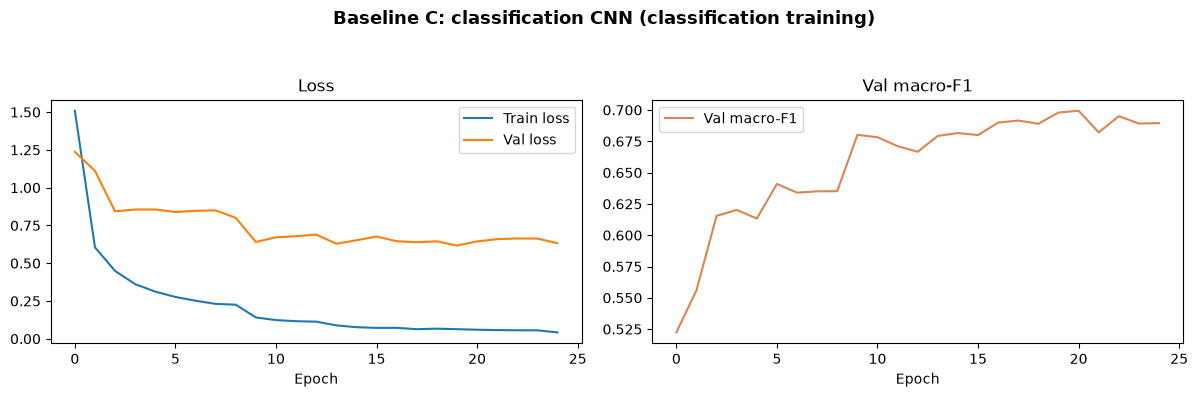

In [15]:
from sklearn.metrics import f1_score as _f1

EPOCHS_CLS, PATIENCE_CLS, LR = 25, 5, 3e-4
N_CLASSES_T4 = len(encoders['articleType'].classes_)

cls_train_ds = CachedFashionImageDataset(
    gallery_df, train_cache, train_index, train_transform, label_col='articleType_grouped_enc')
cls_val_ds = CachedFashionImageDataset(
    query_df, train_cache, train_index, eval_transform, label_col='articleType_grouped_enc')

cls_sampler = get_weighted_sampler(gallery_df, 'articleType_grouped_enc')
cls_train_loader = DataLoader(cls_train_ds, batch_size=64, sampler=cls_sampler, num_workers=0)
cls_val_loader = DataLoader(cls_val_ds, batch_size=256, shuffle=False, num_workers=0)


def fit_classifier(model, train_loader, val_loader, epochs=EPOCHS_CLS,
                   patience=PATIENCE_CLS, lr=LR, name='classifier'):
    criterion = nn.CrossEntropyLoss()
    optimiser = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='max', factor=0.5, patience=2)
    stopper = EarlyStopping(patience=patience, mode='max')
    history = {'train_loss': [], 'val_loss': [], 'val_metric': []}

    for epoch in range(epochs):
        model.train(); tot, n = 0.0, 0
        for imgs, labels in tqdm(train_loader, desc=f'{name} {epoch+1}/{epochs}', leave=False):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            loss = criterion(model(imgs), labels)
            optimiser.zero_grad(); loss.backward(); optimiser.step()
            tot += loss.item() * labels.size(0); n += labels.size(0)
        train_loss = tot / n

        model.eval(); preds, actual, vtot, vn = [], [], 0.0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                logits = model(imgs)
                vtot += criterion(logits, labels).item() * labels.size(0); vn += labels.size(0)
                preds.extend(logits.argmax(1).cpu().numpy()); actual.extend(labels.cpu().numpy())
        val_loss = vtot / vn
        val_f1 = _f1(actual, preds, average='macro', zero_division=0)

        history['train_loss'].append(train_loss); history['val_loss'].append(val_loss)
        history['val_metric'].append(val_f1)
        print(f'Epoch {epoch+1}/{epochs} - train_loss: {train_loss:.4f} - val_loss: {val_loss:.4f} - '
              f'val_macroF1: {val_f1:.4f} - lr: {optimiser.param_groups[0]["lr"]:.2e}')
        scheduler.step(val_f1); stopper(val_f1, model)
        if stopper.early_stop:
            print(f'Early stopping at epoch {epoch+1}')
            break

    model = stopper.load_best_model(model)
    plot_curves(history, f'{name} (classification training)', ylabels=('Loss', 'Val macro-F1'))
    return model, history


torch.manual_seed(RANDOM_STATE)
cls_model = Classifier(ResNetStyleCNN(EMB_DIM), N_CLASSES_T4).to(DEVICE)
cls_model, cls_history = fit_classifier(cls_model, cls_train_loader, cls_val_loader,
                                        name='Baseline C: classification CNN')

In [16]:
# Discard the classification head; the encoder alone is the embedding model.
cls_encoder = cls_model.encoder
gal_cls = embed_with_model(cls_encoder, gallery_df, train_cache, train_index)
qry_cls = embed_with_model(cls_encoder, query_df, train_cache, train_index)

print(f"Classification-CNN embedding dimension: {gal_cls.shape[1]}")
print(f"(sanity) its own classification val macro-F1 peaked at {max(cls_history['val_metric']):.4f} "
      f"-- comparable to Task 1's reported 0.709 for the same architecture\n")

row_cls, s_cls, st_cls, topk_cls = evaluate_embedding("C: Classification CNN", gal_cls, qry_cls)

embedding:   0%|          | 0/111 [00:00<?, ?it/s]

embedding:   0%|          | 0/37 [00:00<?, ?it/s]

Classification-CNN embedding dimension: 128
(sanity) its own classification val macro-F1 peaked at 0.6994 -- comparable to Task 1's reported 0.709 for the same architecture



C: Classification CNN              P@10=0.8234  mAP@10=0.7890  | strict P@10=0.2399  mAP@10=0.1600


## Step 10 - Baseline D: convolutional autoencoder

No labels at all. The network compresses each image through a 128-d bottleneck and reconstructs it,
and the bottleneck becomes the embedding. It tests whether category supervision is necessary. Its
known weakness is that reconstruction loss is dominated by whatever occupies the most pixels, which
here is the white background and the item's colour mass.

Autoencoder shape contract OK: (2, 3, 80, 60) -> 128-d -> (2, 3, 80, 60)


Autoencoder 1/15:   0%|          | 0/222 [00:00<?, ?it/s]

Epoch 1/15 - recon_mse: 0.28025


Autoencoder 2/15:   0%|          | 0/222 [00:00<?, ?it/s]

Epoch 2/15 - recon_mse: 0.12616


...

Epoch 13/15 - recon_mse: 0.05484


Autoencoder 14/15:   0%|          | 0/222 [00:00<?, ?it/s]

Epoch 14/15 - recon_mse: 0.05329


Autoencoder 15/15:   0%|          | 0/222 [00:00<?, ?it/s]

Epoch 15/15 - recon_mse: 0.05318


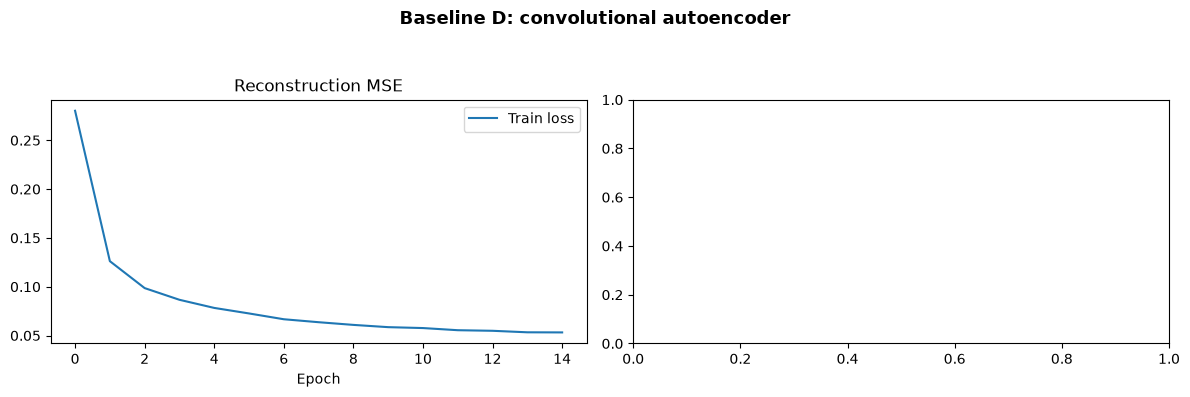

embedding:   0%|          | 0/111 [00:00<?, ?it/s]

embedding:   0%|          | 0/37 [00:00<?, ?it/s]

D: Autoencoder                     P@10=0.7108  mAP@10=0.6500  | strict P@10=0.2486  mAP@10=0.1695


In [17]:
EPOCHS_AE = 15

class ConvAutoencoder(nn.Module):
    """Encoder compresses 3x80x60 -> 128-d bottleneck; decoder rebuilds the image.
    Only the encoder is kept for retrieval."""

    def __init__(self, out_dim=EMB_DIM):
        super().__init__()
        self.out_dim = out_dim
        self.enc = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(),    # 40x30
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.BatchNorm2d(64), nn.ReLU(),   # 20x15
            nn.Conv2d(64, 128, 3, stride=2, padding=1), nn.BatchNorm2d(128), nn.ReLU(), # 10x8
            nn.Conv2d(128, 256, 3, stride=2, padding=1), nn.BatchNorm2d(256), nn.ReLU(),# 5x4
        )
        self.to_emb = nn.Linear(256 * 5 * 4, out_dim)
        self.from_emb = nn.Linear(out_dim, 256 * 5 * 4)
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1),
        )

    def forward(self, x):
        return self.to_emb(self.enc(x).flatten(1))

    def reconstruct(self, x):
        z = self.forward(x)
        h = self.from_emb(z).view(-1, 256, 5, 4)
        out = self.dec(h)
        # The encoder's strided convolutions round the width down (60 -> 30 -> 15 -> 8 -> 4),
        # but transposed convolutions double exactly (4 -> 8 -> 16 -> 32 -> 64), so the decoder
        # overshoots the true 60-pixel width. Resize back to the input's exact size rather than
        # cropping, so the loss compares the whole reconstruction against the whole image.
        return F.interpolate(out, size=x.shape[-2:], mode='bilinear', align_corners=False)


ae_train_ds = CachedFashionImageDataset(gallery_df, train_cache, train_index, eval_transform)
ae_loader = DataLoader(ae_train_ds, batch_size=128, shuffle=True, num_workers=0)

torch.manual_seed(RANDOM_STATE)
ae = ConvAutoencoder(EMB_DIM).to(DEVICE)

# Shape contract: the reconstruction must match the input exactly, or the MSE below
# would broadcast and silently compute the wrong loss.
_probe = torch.zeros(2, 3, IMG_HEIGHT, IMG_WIDTH, device=DEVICE)
assert ae.reconstruct(_probe).shape == _probe.shape, \
    f"autoencoder reconstruction {tuple(ae.reconstruct(_probe).shape)} != input {tuple(_probe.shape)}"
assert ae(_probe).shape == (2, EMB_DIM), "autoencoder embedding has the wrong dimension"
print(f"Autoencoder shape contract OK: {tuple(_probe.shape)} -> {EMB_DIM}-d -> {tuple(_probe.shape)}")
del _probe
ae_opt = torch.optim.AdamW(ae.parameters(), lr=1e-3, weight_decay=1e-5)
ae_history = {'train_loss': [], 'val_metric': []}

for epoch in range(EPOCHS_AE):
    ae.train(); tot, n = 0.0, 0
    for imgs, _ in tqdm(ae_loader, desc=f'Autoencoder {epoch+1}/{EPOCHS_AE}', leave=False):
        imgs = imgs.to(DEVICE)
        loss = F.mse_loss(ae.reconstruct(imgs), imgs)
        ae_opt.zero_grad(); loss.backward(); ae_opt.step()
        tot += loss.item() * imgs.size(0); n += imgs.size(0)
    ae_history['train_loss'].append(tot / n)
    print(f'Epoch {epoch+1}/{EPOCHS_AE} - recon_mse: {tot/n:.5f}')

plot_curves(ae_history, 'Baseline D: convolutional autoencoder', ylabels=('Reconstruction MSE', ''))

gal_ae = embed_with_model(ae, gallery_df, train_cache, train_index)
qry_ae = embed_with_model(ae, query_df, train_cache, train_index)
row_ae, s_ae, st_ae, topk_ae = evaluate_embedding("D: Autoencoder", gal_ae, qry_ae)

### A note on the training budget

An 80-epoch cap with early stopping on validation mAP@10 and patience 8. It stopped at epoch 68 with
a best validation mAP@10 of 0.7974, so it converged inside its budget. The cap was set at 80 because
at 30 epochs mAP@10 was still climbing while the classification baseline had already converged. Rung
0 in Step 11b supplies the budget-matched comparison.

Metric 1/80:   0%|          | 0/450 [00:00<?, ?it/s]

embedding:   0%|          | 0/111 [00:00<?, ?it/s]

embedding:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 1/80 - triplet_loss: 0.2069 - active_triplets: 100.00% - val_mAP@10: 0.5538 - lr: 3.00e-04


Metric 2/80:   0%|          | 0/450 [00:00<?, ?it/s]

...

Epoch 67/80 - triplet_loss: 0.0076 - active_triplets: 4.00% - val_mAP@10: 0.7936 - lr: 2.34e-06


Metric 68/80:   0%|          | 0/450 [00:00<?, ?it/s]

embedding:   0%|          | 0/111 [00:00<?, ?it/s]

embedding:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 68/80 - triplet_loss: 0.0079 - active_triplets: 4.03% - val_mAP@10: 0.7936 - lr: 2.34e-06
Early stopping at epoch 68 (best val mAP@10 = 0.7974)


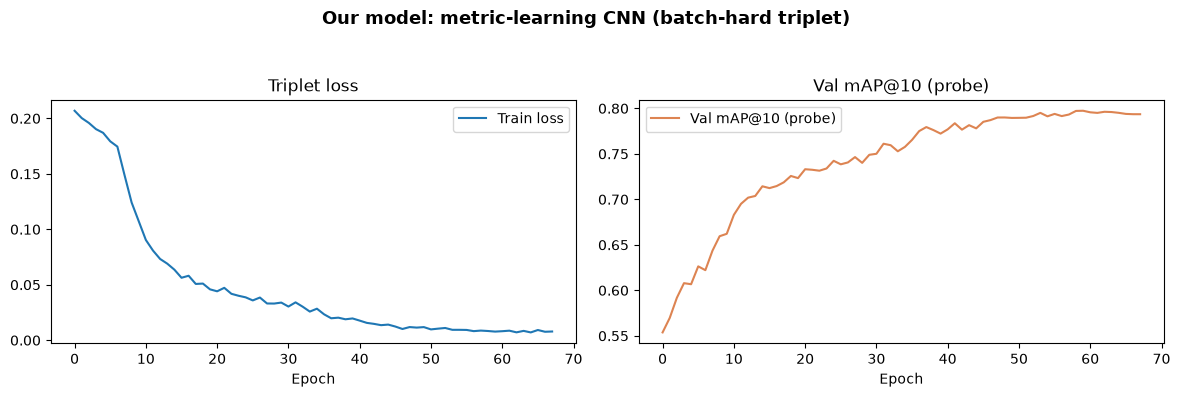

>>> Best validation mAP@10 during training: 0.7974


In [18]:
# Budget raised from 30 to 80 after the first full run: validation mAP@10 was still
# rising monotonically at epoch 30 (0.7299 -> 0.7358 -> 0.7372) and early stopping never
# fired, so 30 was an arbitrary cap rather than convergence. Patience raised 6 -> 8
# because that run showed slow, slightly non-monotonic gains (epoch 22 dipped, then
# recovered and kept climbing) -- a tight patience risks stopping on such a dip.
EPOCHS_METRIC, PATIENCE_METRIC = 80, 8
BATCHES_PER_EPOCH = 450          # ~= 28,800 images/epoch, matching the classifier's epoch size
MARGIN = 0.2


def batch_hard_triplet_loss(emb, labels, margin=MARGIN):
    """For each anchor: hardest positive (furthest same-class) vs hardest negative
    (closest different-class), both taken within the batch."""
    dist = torch.cdist(emb, emb, p=2)
    same = labels[:, None] == labels[None, :]
    eye = torch.eye(len(labels), dtype=torch.bool, device=emb.device)
    pos_mask, neg_mask = same & ~eye, ~same

    d_pos = dist.masked_fill(~pos_mask, -1.0).max(dim=1).values
    d_neg = dist.masked_fill(~neg_mask, float('inf')).min(dim=1).values
    valid = pos_mask.any(dim=1) & neg_mask.any(dim=1)

    losses = F.relu(d_pos - d_neg + margin)[valid]
    active = (losses > 0).float().mean() if len(losses) else torch.tensor(0.0)
    return losses.mean(), float(active)


metric_ds = CachedFashionImageDataset(
    gallery_df, train_cache, train_index, train_transform, label_col='articleType_grouped_enc')
metric_sampler = PKSampler(gallery_df['articleType_grouped_enc'].values,
                           P=P_CLASSES, K=K_PER_CLASS, batches_per_epoch=BATCHES_PER_EPOCH)
metric_loader = DataLoader(metric_ds, batch_sampler=metric_sampler, num_workers=0)

torch.manual_seed(RANDOM_STATE)
metric_model = EmbeddingNet(ResNetStyleCNN(EMB_DIM)).to(DEVICE)
opt = torch.optim.AdamW(metric_model.parameters(), lr=LR, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=2)
stopper = EarlyStopping(patience=PATIENCE_METRIC, mode='max')
metric_history = {'train_loss': [], 'val_metric': [], 'active': []}

for epoch in range(EPOCHS_METRIC):
    metric_model.train(); tot, n, act = 0.0, 0, []
    for imgs, labels in tqdm(metric_loader, desc=f'Metric {epoch+1}/{EPOCHS_METRIC}', leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        loss, frac_active = batch_hard_triplet_loss(metric_model(imgs), labels)
        opt.zero_grad(); loss.backward(); opt.step()
        tot += loss.item() * imgs.size(0); n += imgs.size(0); act.append(frac_active)

    train_loss = tot / n
    val_map = probe_map10(metric_model)
    metric_history['train_loss'].append(train_loss)
    metric_history['val_metric'].append(val_map)
    metric_history['active'].append(float(np.mean(act)))

    print(f'Epoch {epoch+1}/{EPOCHS_METRIC} - triplet_loss: {train_loss:.4f} - '
          f'active_triplets: {np.mean(act):.2%} - val_mAP@10: {val_map:.4f} - '
          f'lr: {opt.param_groups[0]["lr"]:.2e}')

    sched.step(val_map); stopper(val_map, metric_model)
    if stopper.early_stop:
        print(f'Early stopping at epoch {epoch+1} (best val mAP@10 = {stopper.best_score:.4f})')
        break

metric_model = stopper.load_best_model(metric_model)
plot_curves(metric_history, 'Our model: metric-learning CNN (batch-hard triplet)',
            ylabels=('Triplet loss', 'Val mAP@10 (probe)'))
print(f'>>> Best validation mAP@10 during training: {max(metric_history["val_metric"]):.4f}')

In [19]:
gal_metric = embed_with_model(metric_model, gallery_df, train_cache, train_index)
qry_metric = embed_with_model(metric_model, query_df, train_cache, train_index)
row_metric, s_metric, st_metric, topk_metric = evaluate_embedding(
    "E: Metric learning (ours)", gal_metric, qry_metric)

embedding:   0%|          | 0/111 [00:00<?, ?it/s]

embedding:   0%|          | 0/37 [00:00<?, ?it/s]

E: Metric learning (ours)          P@10=0.8295  mAP@10=0.7961  | strict P@10=0.2154  mAP@10=0.1363


## Step 11b - Extending our model: a controlled ablation ladder

Step 12 shows Baseline C at 0.7890 and the Step 11 model at 0.7960, a gap of 0.0070 with overlapping
intervals, so neither wins. Two models that differ only in their loss should not land inside each
other's intervals by accident, which suggests each loss has learned something the other has not.

The metric model was therefore pushed further as a controlled ladder: one change per run, everything
else pinned to the Step 11 recipe, and a fixed 50-epoch budget so no rung can win by training longer.
The harness is `experiments/rung_ablation.py`. Every number in the table below comes from this
notebook's `evaluate_embedding`, and all three promoted rungs re-score to four decimal places.

Rungs F, G and H earn places alongside the baselines. The rest are reported for completeness,
including the ones that failed. Rung 1 was stopped early for time and is reported as untested.

In [20]:
# ── The ladder as actually run, read straight from the harness's result files ──
EXP_DIR = Path('../experiments')
LADDER_LOG = EXP_DIR / 'log'        # Quan's reorg moved result/progress files here

RUNG_NOTES = {
    'rung0-50':            ('rung 0',  'Step 11 recipe at the fixed 50-epoch budget (ladder baseline)'),
    'rung2-gem-50':        ('rung 2',  'GeM pooling (learnable p) instead of global average pooling'),
    'rung3-colour':        ('rung 3',  '256-d split embedding, a second triplet on baseColour'),
    'rung3b-ce-50':        ('rung 3b', 'colour block supervised by cross-entropy, weight 1.00'),
    'rung3b-w0.03-50':     ('rung 3b', 'colour block supervised by cross-entropy, weight 0.03'),
    'rung3b-w0.10-50':     ('rung 3b', 'colour block supervised by cross-entropy, weight 0.10'),
    'rung4-aux-50':        ('rung 4',  'auxiliary CE heads on four metadata columns Step 11 never used'),
    'rung5-arcface-50':    ('rung 5',  'ArcFace additive angular margin on the embedding'),
    'rung6-arc-colour-50': ('rung 6',  'rungs 5 + 3b combined: ArcFace on semantics, CE on colour'),
}

ladder_rows = []
for path in sorted(LADDER_LOG.glob('result_rung*.json')):
    tag = path.stem.replace('result_', '')
    if tag not in RUNG_NOTES:
        continue                                   # partial runs kept on disk for reference
    r = json.loads(path.read_text())
    rung, what = RUNG_NOTES[tag]
    ladder_rows.append({'Rung': rung, 'What changed': what, 'mAP@10': r['mAP10'],
                        'CI': f"{r['ci_low']:.3f}-{r['ci_high']:.3f}",
                        'strict': r['mAP10_strict'], 'dim': r['emb_dim'],
                        'epochs': r['epochs_run']})

ladder = pd.DataFrame(ladder_rows).sort_values('mAP@10', ascending=False).reset_index(drop=True)
display(ladder.round(4))

off_budget = ladder[ladder['epochs'] != 50]
if len(off_budget):
    print("Rungs that did not run the standard 50 epochs — read these with that caveat:")
    for _, r in off_budget.iterrows():
        why = 'early-stopped on the patience rule (a collapse, not convergence)' if r['epochs'] < 50 \
              else 'ran before the budget was fixed at 50'
        print(f"  {r['Rung']:8s} {r['epochs']:3d} epochs — {why}")


,Rung,What changed,mAP@10,CI,strict,dim,epochs
0,rung 5,ArcFace additive angular margin on the embedding,0.8214,0.815-0.828,0.1447,128,50
1,rung 6,"rungs 5 + 3b combined: ArcFace on semantics, C...",0.8132,0.806-0.820,0.3805,256,50
2,rung 0,Step 11 recipe at the fixed 50-epoch budget (l...,0.7779,0.771-0.784,0.1353,128,50
3,rung 3,"256-d split embedding, a second triplet on bas...",0.7753,0.768-0.782,0.1406,256,50
4,rung 3b,"colour block supervised by cross-entropy, weig...",0.7706,0.763-0.777,0.3916,256,50
5,rung 2,GeM pooling (learnable p) instead of global av...,0.7657,0.759-0.773,0.1463,128,50
6,rung 4,auxiliary CE heads on four metadata columns St...,0.7563,0.749-0.763,0.1357,128,50
7,rung 3b,"colour block supervised by cross-entropy, weig...",0.7492,0.742-0.756,0.4075,256,50
8,rung 3b,"colour block supervised by cross-entropy, weig...",0.4138,0.407-0.421,0.2379,256,23


Rungs that did not run the standard 50 epochs — read these with that caveat:
  rung 3b   23 epochs — early-stopped on the patience rule (a collapse, not convergence)


In [21]:
# ── Promote three rungs to full approaches, re-scored with THIS notebook's evaluator ──
import sys
sys.path.insert(0, str(EXP_DIR.resolve()))
from rung_ablation import (ResNetStyleCNN as LadderCNN,
                           EmbeddingNet as LadderEmbeddingNet,
                           ColourEmbeddingNet as LadderColourNet)

PROMOTED = [
    ("F: + ArcFace (rung 5)",           'rung5-arcface-50'),
    ("G: + colour CE w=0.10 (rung 3b)", 'rung3b-w0.10-50'),
    ("H: ArcFace + colour (rung 6)",    'rung6-arc-colour-50'),
]


def load_rung(tag):
    """Rebuild a rung's architecture from its own state dict, then load the weights.
    Every shape is read off the checkpoint, so this cannot drift from what was trained."""
    sd = torch.load(EXP_DIR / f'model_{tag}.pt', map_location=DEVICE)
    n_arc = sd['arc.W'].shape[0] if 'arc.W' in sd else None
    if 'ce_W' in sd:                                    # rung 3/3b/6: split colour embedding
        enc = LadderCNN(LadderColourNet.SEM + LadderColourNet.COL)
        model = LadderColourNet(enc, n_colours=sd['ce_W'].shape[0], arcface_classes=n_arc)
    else:
        enc = LadderCNN(EMB_DIM)
        model = LadderEmbeddingNet(enc, arcface_classes=n_arc)
    model.load_state_dict(sd, strict=True)              # strict: no silent shape mismatch
    return model.to(DEVICE).eval()


rung_models, rung_eval, rung_gal = {}, {}, {}
for name, tag in PROMOTED:
    ckpt = EXP_DIR / f'model_{tag}.pt'
    if not ckpt.exists():
        print(f"SKIPPED {name}: {ckpt.name} not on disk"); continue

    model = load_rung(tag)
    gal = embed_with_model(model, gallery_df, train_cache, train_index)
    qry = embed_with_model(model, query_df, train_cache, train_index)
    row, simple, strict, topk = evaluate_embedding(name, gal, qry)

    rung_models[name], rung_eval[name], rung_gal[name] = model, (row, simple, strict, topk), gal

    # Parity: this notebook's evaluator vs the harness that trained the checkpoint.
    reported = json.loads((LADDER_LOG / f'result_{tag}.json').read_text())['mAP10']
    delta = row['mAP@10'] - reported
    flag = 'agree' if abs(delta) < 5e-4 else f'DIFFER by {delta:+.4f} — investigate'
    print(f"{'':34s} harness reported {reported:.4f}, re-scored here {row['mAP@10']:.4f}  [{flag}]")

print(f"\nPromoted {len(rung_eval)} of {len(PROMOTED)} rungs into the comparison.")


embedding:   0%|          | 0/111 [00:00<?, ?it/s]

embedding:   0%|          | 0/37 [00:00<?, ?it/s]

F: + ArcFace (rung 5)              P@10=0.8444  mAP@10=0.8214  | strict P@10=0.2243  mAP@10=0.1447
                                   harness reported 0.8214, re-scored here 0.8214  [agree]


embedding:   0%|          | 0/111 [00:00<?, ?it/s]

embedding:   0%|          | 0/37 [00:00<?, ?it/s]

G: + colour CE w=0.10 (rung 3b)    P@10=0.7922  mAP@10=0.7492  | strict P@10=0.4742  mAP@10=0.4075
                                   harness reported 0.7492, re-scored here 0.7492  [agree]


embedding:   0%|          | 0/111 [00:00<?, ?it/s]

embedding:   0%|          | 0/37 [00:00<?, ?it/s]

H: ArcFace + colour (rung 6)       P@10=0.8370  mAP@10=0.8132  | strict P@10=0.4521  mAP@10=0.3805
                                   harness reported 0.8132, re-scored here 0.8132  [agree]

Promoted 3 of 3 rungs into the comparison.


As seen with the result, the rungs separate into three outcomes.

**Two changes did not help.** GeM pooling (rung 2, 0.7657) lands inside rung 0's interval. Auxiliary
metadata heads (rung 4, 0.7563) are worse, with an interval of 0.749-0.763 clear of rung 0's
0.771-0.784, so the extra supervision measurably costs ranking quality.

**One change trades one metric for the other.** A supervised colour block (rung 3b) moves the strict
score from 0.1353 to 0.4075 at weight 0.10, and costs simple ranking quality to do it. A second
triplet on colour (rung 3, strict 0.1406) buys almost none of that, so the gain comes from the loss.
At weight 1.00 the run collapses to 0.4138 and early-stops at epoch 23.

**One change lifts the headline metric.** ArcFace (rung 5, 0.8214) acts on the same normalised sphere
the triplet already uses, so the two share one embedding instead of competing for it (Deng et al.,
2019). It is the only rung whose interval clears rung 0's. Rung 6 combines it with the colour block.

## Step 12 - Comparing all eight approaches

Bootstrap 95% confidence intervals resample queries, matching Task 1's methodology. Two models are
only meaningfully different if their intervals do not overlap. A to E are the four baselines and the
Step 11 model; F, G and H are the three promoted rungs, re-scored above on the same split.

In [22]:
def bootstrap_ci(per_query, n_boot=1000, ci=0.95, seed=RANDOM_STATE):
    """Resample queries with replacement to get a CI on a mean per-query score."""
    rng = np.random.default_rng(seed)
    v = np.asarray(per_query); n = len(v)
    means = np.array([v[rng.integers(0, n, n)].mean() for _ in range(n_boot)])
    a = (1 - ci) / 2
    return means.mean(), np.quantile(means, a), np.quantile(means, 1 - a)


all_models = [
    ("A: Raw pixels",            row_pixels, s_pixels, st_pixels),
    ("B: Colour histogram",      row_hist,   s_hist,   st_hist),
    ("C: Classification CNN",    row_cls,    s_cls,    st_cls),
    ("D: Autoencoder",           row_ae,     s_ae,     st_ae),
    ("E: Metric learning (ours)",row_metric, s_metric, st_metric),
    # F/G/H are appended from Step 11b, scored by this same evaluator.
] + [(name, *rung_eval[name][:3]) for name, _ in PROMOTED if name in rung_eval]

rows = []
for name, row, simple, strict in all_models:
    m, lo, hi = bootstrap_ci(simple[f'AP@{K_PRIMARY}'])
    ms, los, his = bootstrap_ci(strict[f'AP@{K_PRIMARY}'])
    rows.append({
        'Model': name,
        'P@1': row['P@1'], 'P@5': row['P@5'], 'P@10': row['P@10'], 'P@20': row['P@20'],
        'Hit@10': row['Hit@10'],
        'mAP@10': m, 'mAP@10 CI': f'{lo:.3f}-{hi:.3f}',
        'mAP@10 strict': ms, 'strict CI': f'{los:.3f}-{his:.3f}',
    })

comparison = pd.DataFrame(rows)
pd.set_option('display.width', 200)
display(comparison.round(4))

print(f"\nRandom-ranker floor -- simple: {rand_simple:.4f}, strict: {rand_strict:.4f}")

,Model,P@1,P@5,P@10,P@20,Hit@10,mAP@10,mAP@10 CI,mAP@10 strict,strict CI
0,A: Raw pixels,0.7342,0.6747,0.6427,0.6060,0.9348,0.5707,0.563-0.578,0.1602,0.155-0.165
1,B: Colour histogram,0.3715,0.3143,0.2891,0.2635,0.7321,0.2080,0.203-0.213,0.1121,0.108-0.116
2,C: Classification CNN,0.8401,0.8289,0.8234,0.8176,0.9373,0.7890,0.782-0.796,0.1599,0.155-0.165
3,D: Autoencoder,0.7985,0.7407,0.7108,0.6784,0.9543,0.6499,0.643-0.657,0.1694,0.165-0.174
4,E: Metric learning (ours),0.8366,0.8320,0.8295,0.8273,0.9334,0.7960,0.789-0.803,0.1361,0.132-0.140
5,F: + ArcFace (rung 5),0.8453,0.8445,0.8444,0.8445,0.9146,0.8213,0.815-0.828,0.1446,0.140-0.149
6,G: + colour CE w=0.10 (rung 3b),0.8116,0.7980,0.7922,0.7812,0.9318,0.7491,0.742-0.756,0.4072,0.400-0.415
7,H: ArcFace + colour (rung 6),0.8444,0.8404,0.8370,0.8315,0.9153,0.8132,0.806-0.820,0.3803,0.373-0.387



Random-ranker floor -- simple: 0.0912, strict: 0.0117


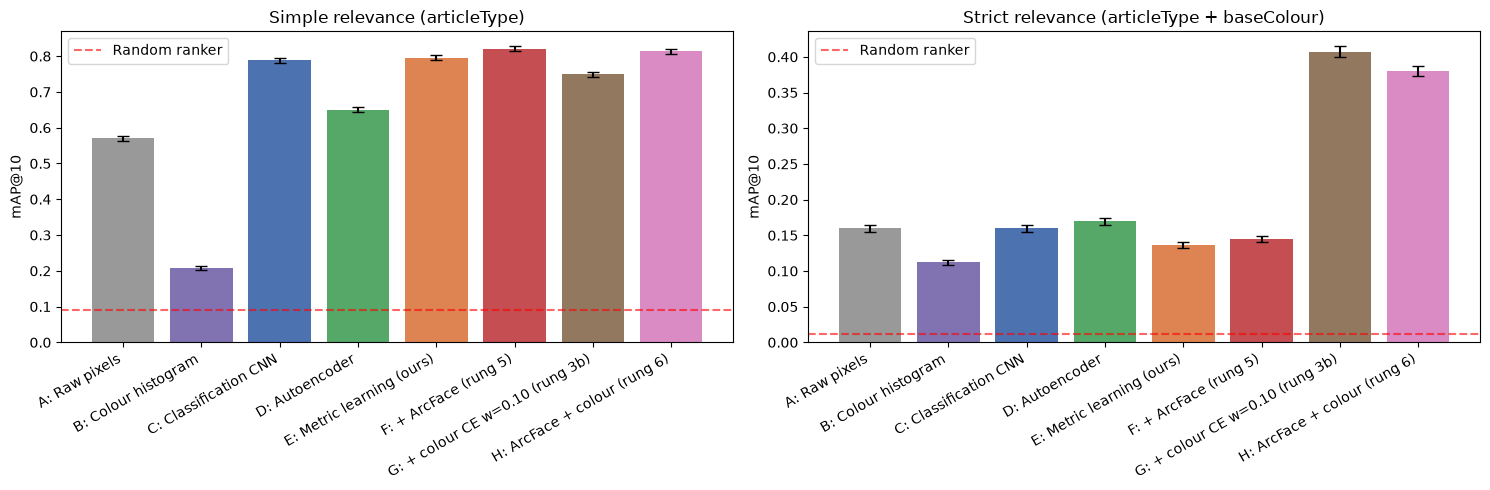

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, col, ci_col, title in [
        (axes[0], 'mAP@10', 'mAP@10 CI', 'Simple relevance (articleType)'),
        (axes[1], 'mAP@10 strict', 'strict CI', 'Strict relevance (articleType + baseColour)')]:
    means = comparison[col].values
    los = np.array([float(s.split('-')[0]) for s in comparison[ci_col]])
    his = np.array([float(s.split('-')[1]) for s in comparison[ci_col]])
    ax.bar(comparison['Model'], means, yerr=[means - los, his - means], capsize=4,
           color=['#999999', '#8172B2', '#4C72B0', '#55A868', '#DD8452',
                  '#C44E52', '#937860', '#DA8BC3'][:len(comparison)])
    ax.axhline(rand_simple if 'strict' not in col else rand_strict,
               ls='--', color='red', alpha=0.6, label='Random ranker')
    ax.set_ylabel('mAP@10'); ax.set_title(title); ax.legend()
    ax.tick_params(axis='x', rotation=30)
    for lbl in ax.get_xticklabels():
        lbl.set_ha('right')
plt.tight_layout(); plt.show()

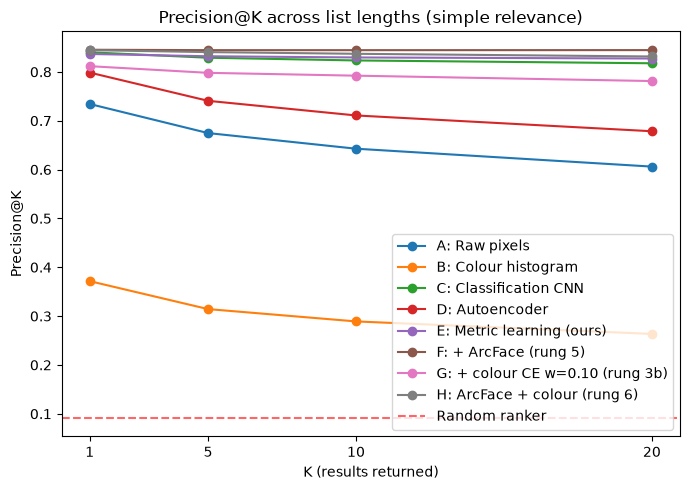

In [24]:
# Precision@K curves -- does any model's advantage depend on how many results are shown?
fig, ax = plt.subplots(figsize=(7, 5))
for name, row, _, _ in all_models:
    ax.plot(K_VALUES, [row[f'P@{k}'] for k in K_VALUES], marker='o', label=name)
ax.axhline(rand_simple, ls='--', color='red', alpha=0.6, label='Random ranker')
ax.set_xlabel('K (results returned)'); ax.set_ylabel('Precision@K')
ax.set_title('Precision@K across list lengths (simple relevance)')
ax.set_xticks(K_VALUES); ax.legend(); plt.tight_layout(); plt.show()

The training budgets are not equal, so they are stated here.

| Approach | Epoch budget | Why |
|---|---|---|
| C: Classification CNN | 25, patience 5 | Task 1's setting, inherited unchanged |
| D: Autoencoder | 15 | reconstruction converges early |
| E: Metric learning (ours) | 80 cap, stopped at 68 | mAP@10 was still rising at epoch 30 |
| F, G, H (ladder rungs) | 50, fixed | one budget for every rung |

Comparing E against F compares 68 epochs against 50, so the obvious objection is that F is only
trained differently. Rung 0 answers it, being E's recipe at 50 epochs: rung 0 scores 0.7779 and E at
68 epochs scores 0.7960, so 18 further epochs bought +0.0181, while F at 50 epochs scores 0.8213, or
+0.0434 over rung 0. F's interval (0.815-0.828) is separated from rung 0's, and F also clears C's
0.7890 (0.782-0.796) with no overlap.

## Step 13 - Qualitative results

Real queries with their Top-5 neighbours from the two strongest approaches, green for a relevant hit
and red for a miss under the simple definition. This is where the proxy caveat from Step 3 becomes
visible, since some red results are ones a shopper would consider perfectly good.

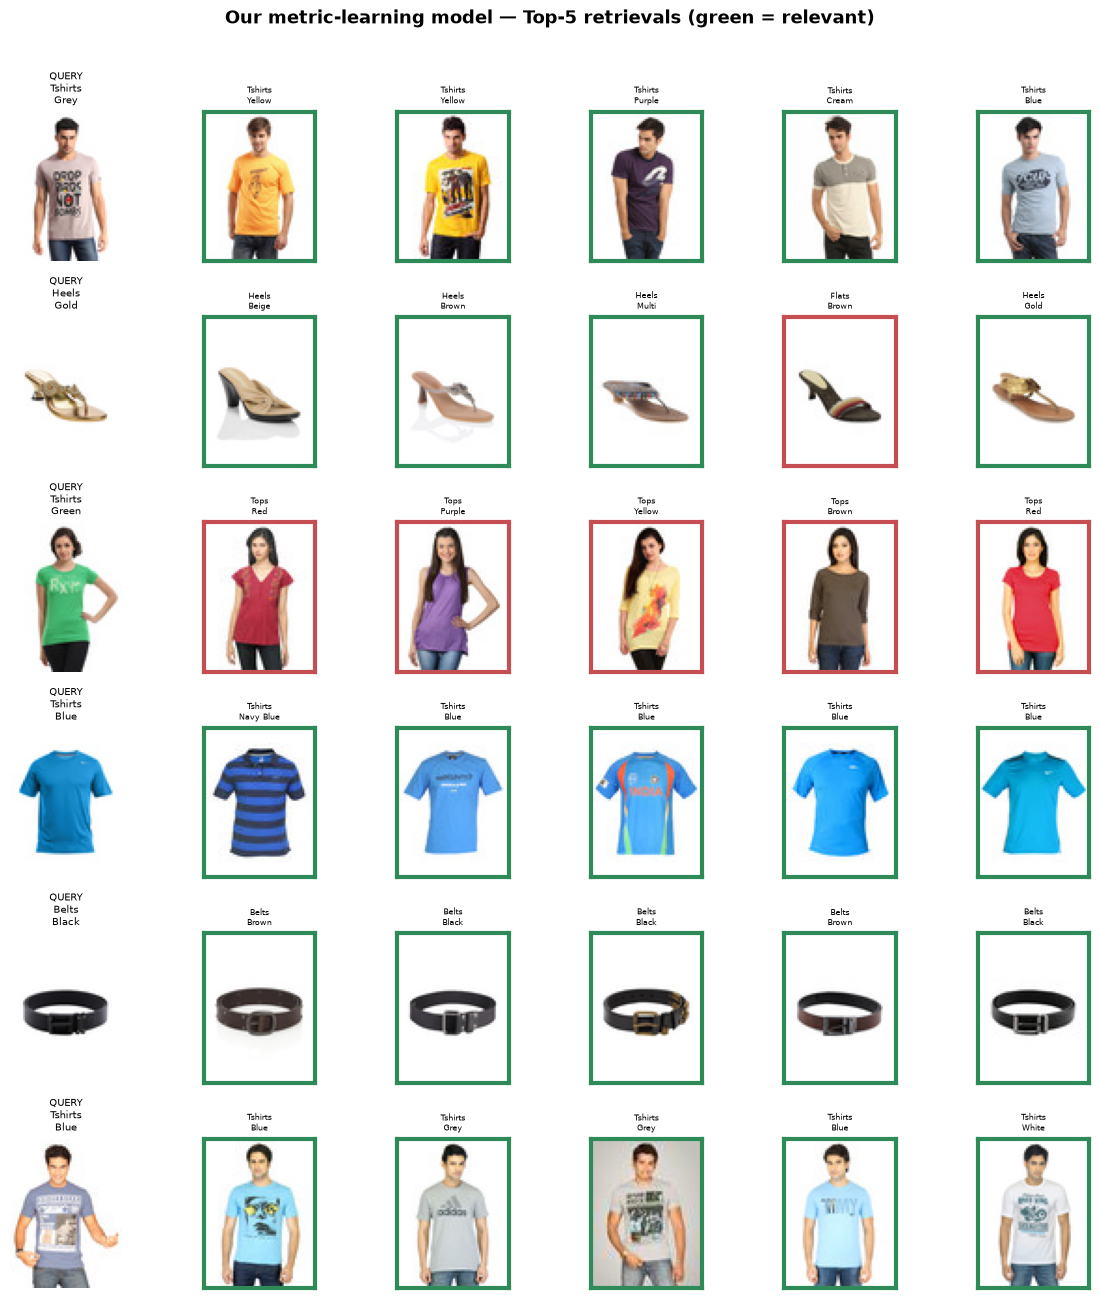

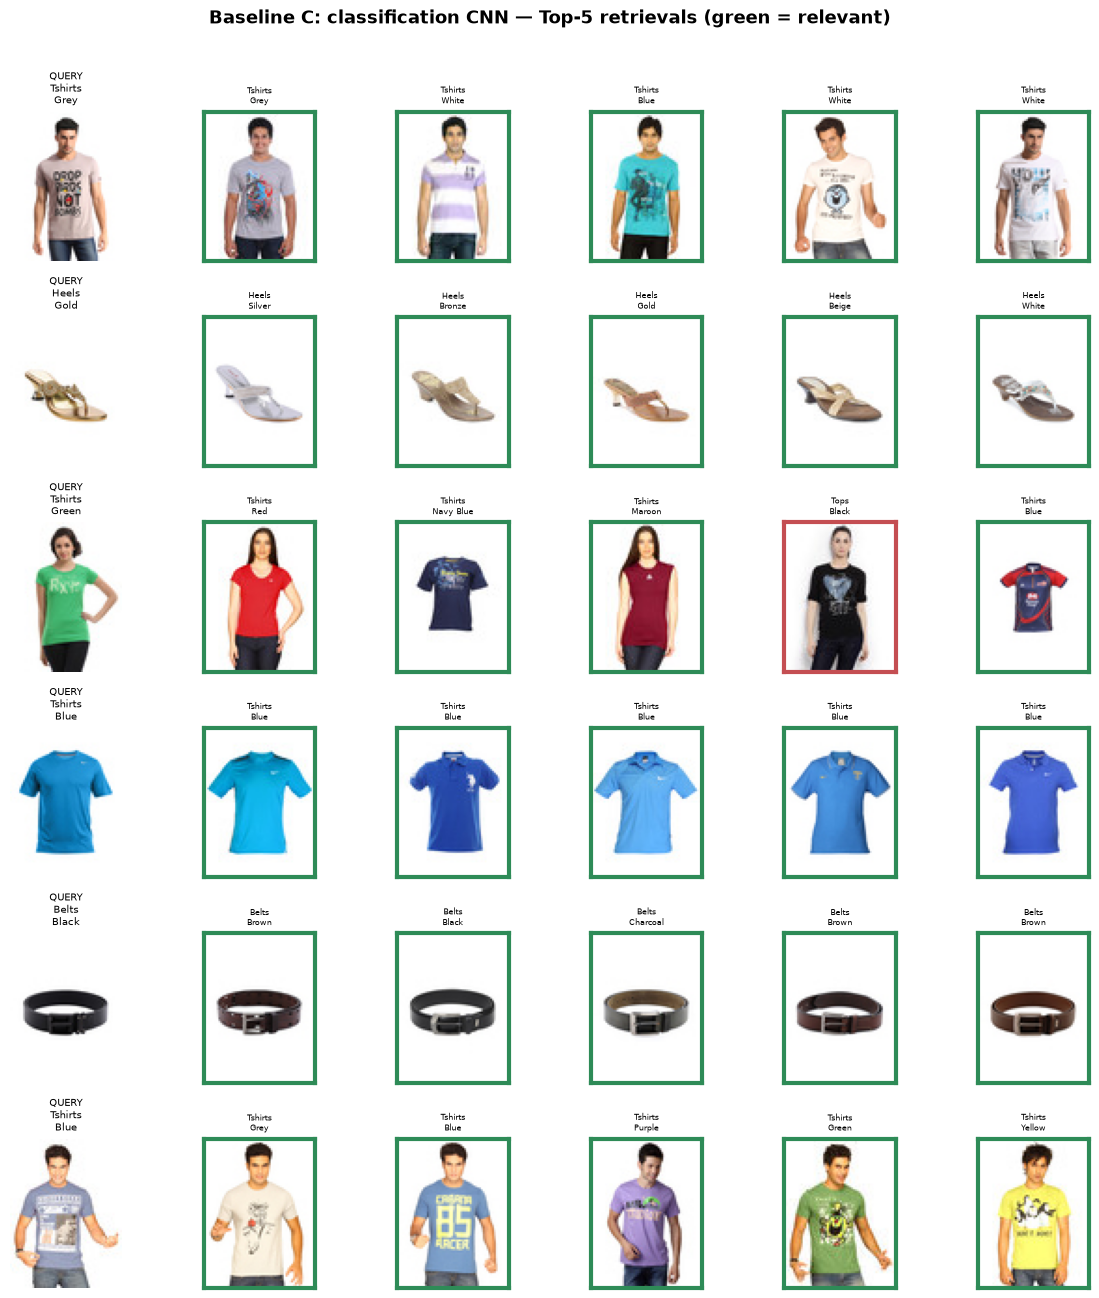

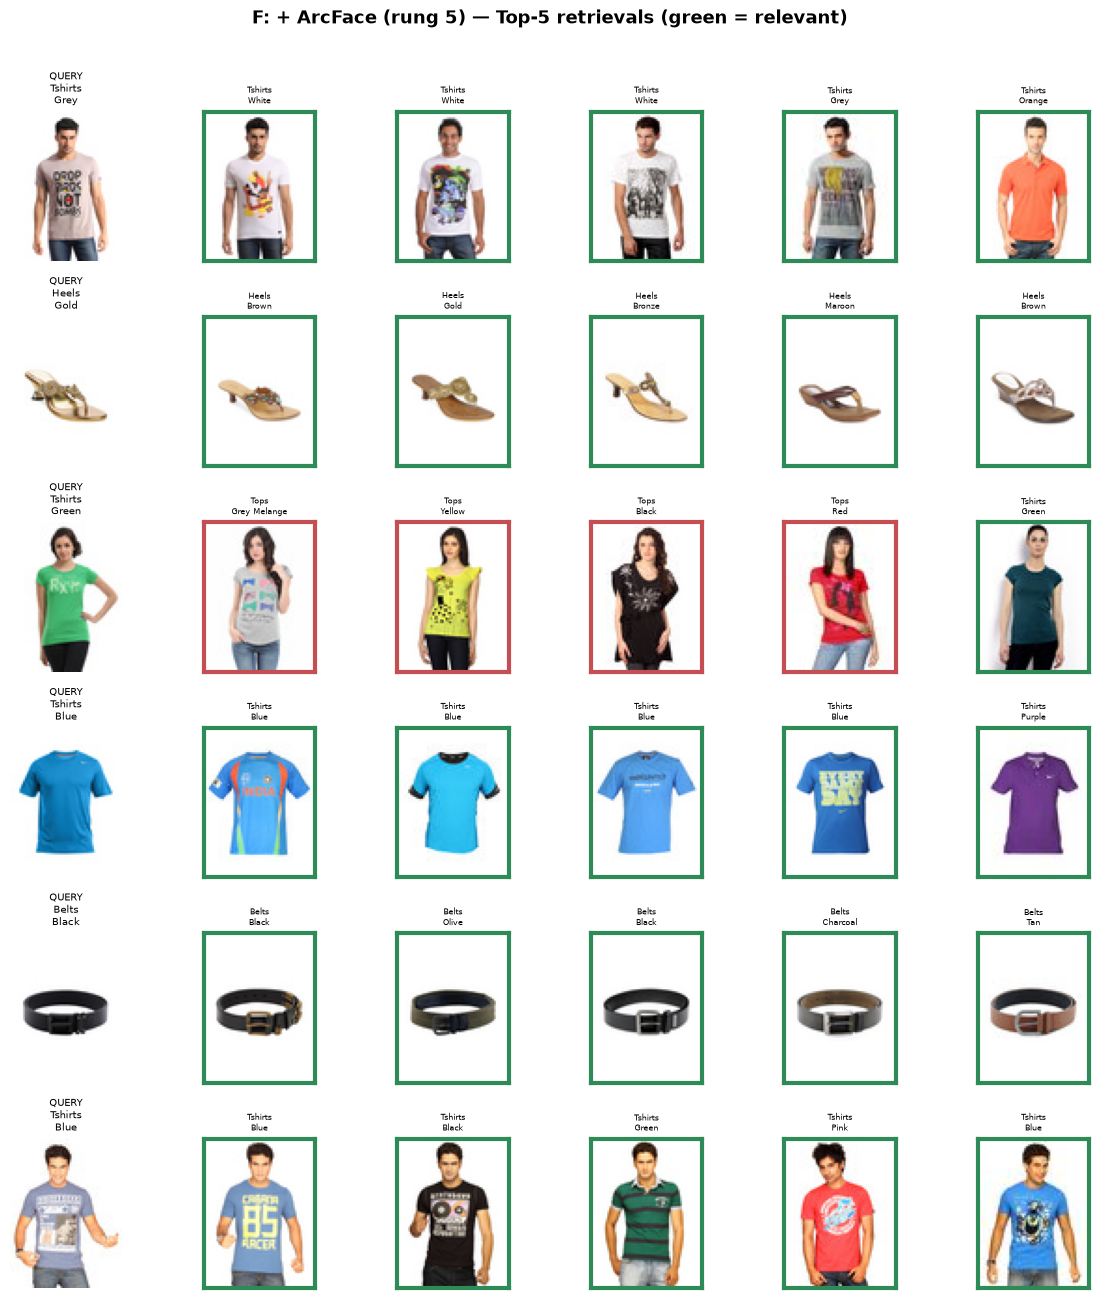

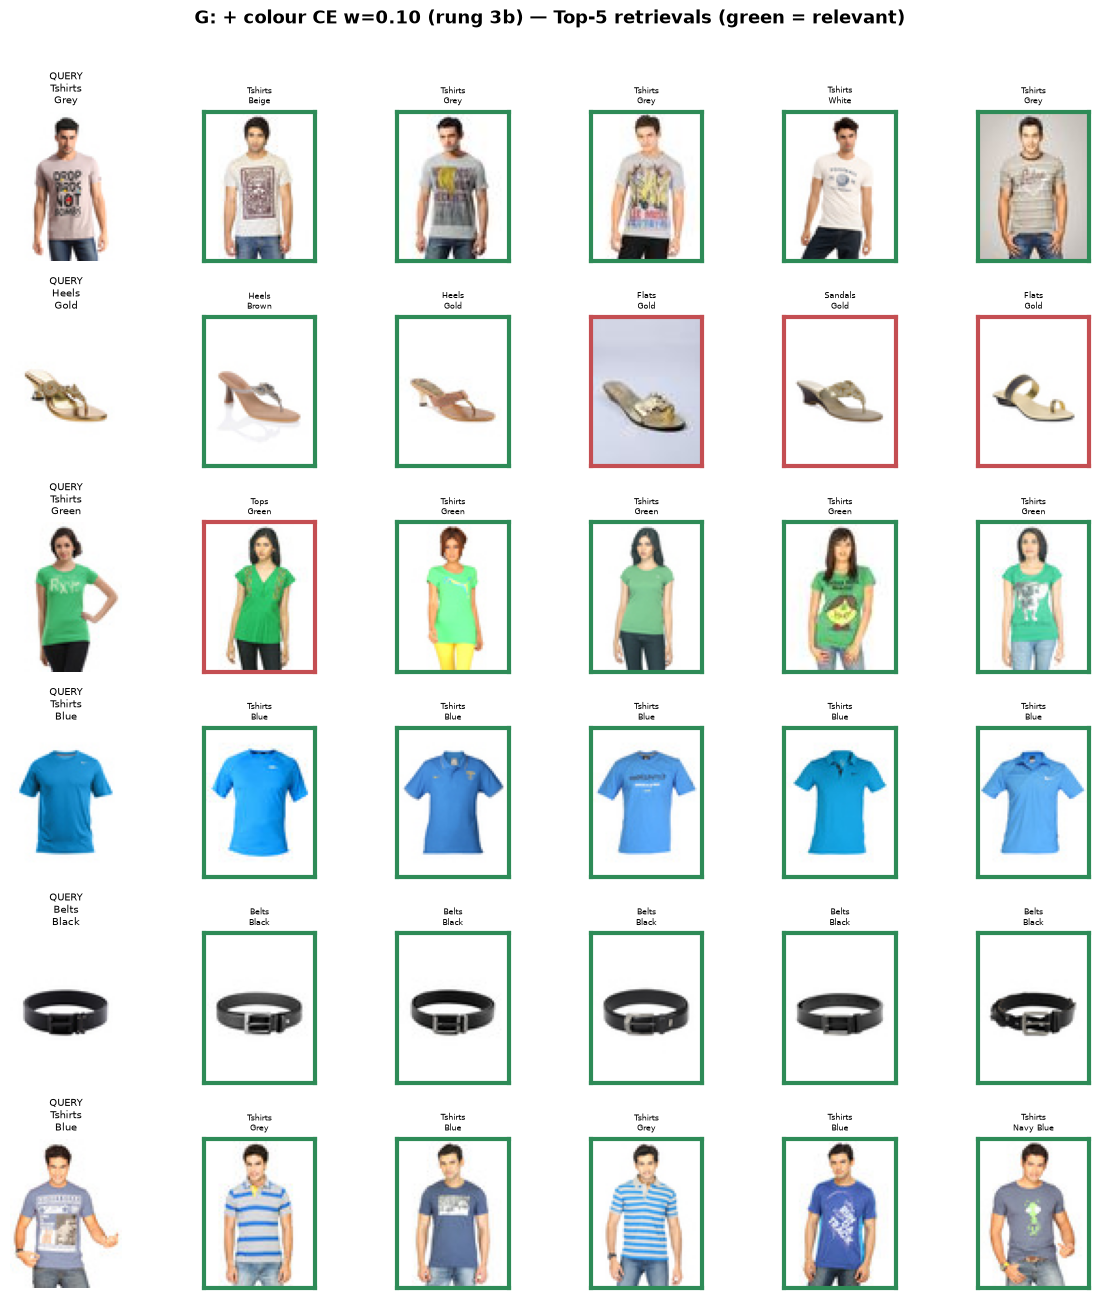

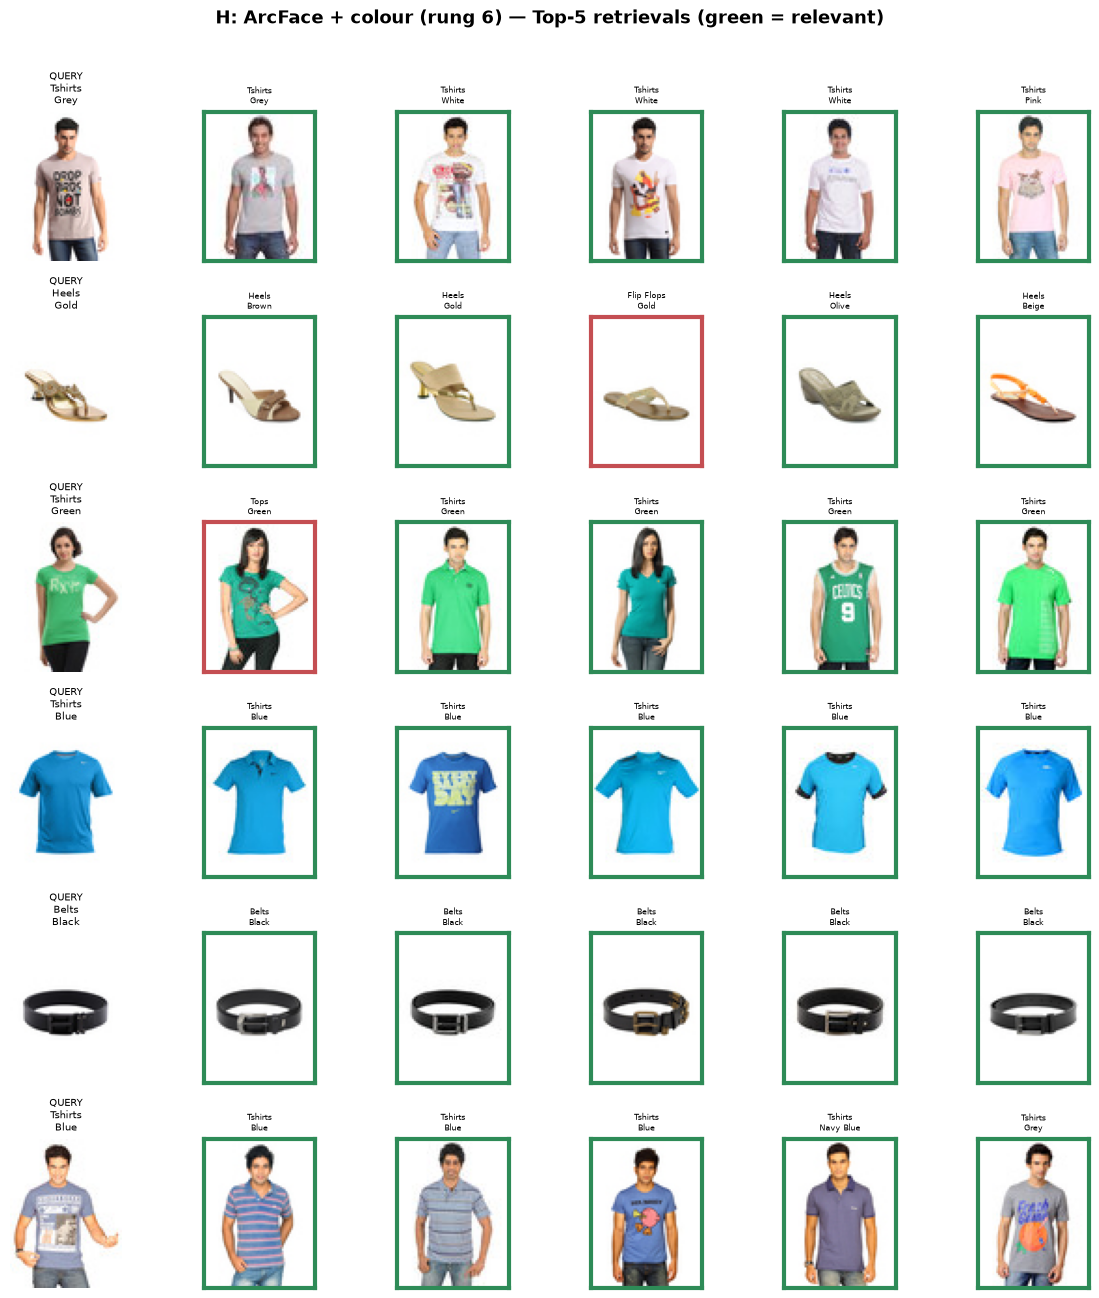

In [25]:
def show_retrievals(topk_idx, title, n_queries=6, k=5, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    picks = rng.choice(len(query_df), size=n_queries, replace=False)
    fig, axes = plt.subplots(n_queries, k + 1, figsize=(2 * (k + 1), 2.2 * n_queries))
    for r, qi in enumerate(picks):
        q_row = query_df.iloc[qi]
        axes[r, 0].imshow(train_cache[train_index[str(q_row['id'])]])
        axes[r, 0].set_title(f"QUERY\n{q_row['articleType_grouped']}\n{q_row['baseColour']}", fontsize=7)
        axes[r, 0].axis('off')
        for c in range(k):
            gi = topk_idx[qi, c]
            g_row = gallery_df.iloc[gi]
            ax = axes[r, c + 1]
            ax.imshow(train_cache[train_index[str(g_row['id'])]])
            hit = g_row['articleType_grouped'] == q_row['articleType_grouped']
            for spine in ax.spines.values():
                spine.set_edgecolor('#2E8B57' if hit else '#C44E52')
                spine.set_linewidth(3)
            ax.set_xticks([]); ax.set_yticks([])
            ax.set_title(f"{g_row['articleType_grouped']}\n{g_row['baseColour']}", fontsize=6)
    fig.suptitle(title, fontweight='bold', fontsize=13)
    plt.tight_layout(rect=[0, 0, 1, 0.97]); plt.show()


show_retrievals(topk_metric, 'Our metric-learning model — Top-5 retrievals (green = relevant)')
show_retrievals(topk_cls, 'Baseline C: classification CNN — Top-5 retrievals (green = relevant)')
for _name, _ in PROMOTED:
    if _name in rung_eval:
        show_retrievals(rung_eval[_name][3], f'{_name} — Top-5 retrievals (green = relevant)')

## Step 14 - Ultimate judgement

Four criteria applied in a fixed order, and one has to be disqualified as a tiebreak.

1. **Simple relevance decides who is in contention**, not who wins. A model joins the leading set if
   its bootstrap interval overlaps the leader's, because choosing between overlapping intervals is
   choosing noise.
2. **Strict relevance is descriptive, not decisive.** G and H are trained on `baseColour`, so their
   strict scores restate their training signal. It was a fair diagnostic when none of A to E saw
   colour supervision, and stops being one the moment a contender does. The code below detects this
   and refuses to break the tie on it.
3. **Independent attributes break the tie instead**: `gender`, `usage` and `season`, which no
   contender trained on. `subCategory` is excluded, being a coarsening of `articleType`.
4. **Cost to serve and stability across K** are vetoes rather than promotions.

If the independent attributes cannot separate the contenders, no winner is manufactured: the cheaper
artifact ships and the alternative is named.

In [26]:
def _ci(s):
    lo, hi = s.split('-'); return float(lo), float(hi)


comparison['_lo'] = [_ci(s)[0] for s in comparison['mAP@10 CI']]
comparison['_hi'] = [_ci(s)[1] for s in comparison['mAP@10 CI']]

# Which contenders had baseColour supervision? Read from the ladder's own result files
# so this can never drift from what was actually trained.
TRAINED_ON_COLOUR = set()
for _name, _tag in PROMOTED:
    if _name in rung_eval and json.loads((LADDER_LOG / f'result_{_tag}.json').read_text()).get('colour_loss'):
        TRAINED_ON_COLOUR.add(_name)

TOPK_BY_NAME = {'A: Raw pixels': topk_pixels, 'B: Colour histogram': topk_hist,
                'C: Classification CNN': topk_cls, 'D: Autoencoder': topk_ae,
                'E: Metric learning (ours)': topk_metric}
DIM_BY_NAME = {'A: Raw pixels': gal_pixels.shape[1], 'B: Colour histogram': gal_hist.shape[1],
               'C: Classification CNN': gal_cls.shape[1], 'D: Autoencoder': gal_ae.shape[1],
               'E: Metric learning (ours)': gal_metric.shape[1]}
TOPK_BY_NAME.update({n: rung_eval[n][3] for n, _ in PROMOTED if n in rung_eval})
DIM_BY_NAME.update({n: rung_gal[n].shape[1] for n, _ in PROMOTED if n in rung_gal})

leader = comparison.loc[comparison['mAP@10'].idxmax()]
leading = comparison[comparison['_hi'] >= leader['_lo']].copy()
beaten = comparison[comparison['_hi'] < leader['_lo']]

print("=== Criterion 1: ranking quality — who is statistically in contention? ===")
print(f"Leader: {leader['Model']}  mAP@10={leader['mAP@10']:.4f} "
      f"(CI {leader['_lo']:.3f}-{leader['_hi']:.3f})")
for _, r in leading.sort_values('mAP@10', ascending=False).iterrows():
    print(f"    in contention   {r['Model']:34s} mAP@10={r['mAP@10']:.4f}  CI {r['_lo']:.3f}-{r['_hi']:.3f}")
print(f"  {len(leading)} in contention, {len(beaten)} statistically beaten by the leader")

print("\n=== Criterion 2: strict relevance — DESCRIPTIVE, and here is why ===")
print(leading[['Model', 'mAP@10', 'mAP@10 strict']]
      .sort_values('mAP@10 strict', ascending=False).round(4).to_string(index=False))
_colour_contenders = [m for m in leading['Model'] if m in TRAINED_ON_COLOUR]
strict_is_fair = not (_colour_contenders and len(_colour_contenders) < len(leading))
if strict_is_fair:
    print("  No contender had baseColour supervision, so strict relevance is a fair diagnostic here.")
else:
    print("  Strict relevance scores a baseColour match, and these contenders were TRAINED on baseColour:")
    for m in _colour_contenders:
        print(f"      {m}")
    print("  Their strict advantage restates that training signal; it is not independent evidence of")
    print("  better visual similarity. Criterion 2 is therefore NOT used to break this tie.")

print("\n=== Criterion 3: independent attributes (no contender trained on these) ===")
INDEPENDENT_ATTRS = ['gender', 'usage', 'season']


def _attr_p_at_k(topk_idx, attr, k=K_PRIMARY):
    """P@k where relevance = matching an attribute that was never a training signal."""
    g = gallery_df[attr].astype(str).to_numpy()
    q = query_df[attr].astype(str).to_numpy()
    return float((g[topk_idx[:, :k]] == q[:, None]).mean())


indep = pd.DataFrame([{'Model': m,
                       **{f'P@10 ({a})': _attr_p_at_k(TOPK_BY_NAME[m], a) for a in INDEPENDENT_ATTRS}}
                      for m in leading['Model'] if m in TOPK_BY_NAME])
indep['mean'] = indep[[f'P@10 ({a})' for a in INDEPENDENT_ATTRS]].mean(axis=1)
print(indep.sort_values('mean', ascending=False).round(4).to_string(index=False))
print("  chance level: " + ", ".join(
    f"{a} {gallery_df[a].astype(str).value_counts(normalize=True).iloc[0]:.4f}" for a in INDEPENDENT_ATTRS))

SEPARATION_THRESHOLD = 0.01          # below this, treat the contenders as indistinguishable
_spread = float(indep['mean'].max() - indep['mean'].min()) if len(indep) > 1 else 0.0

print("\n=== Criterion 4: cost to serve, and stability across list lengths ===")
for name in comparison['Model']:
    print(f"  {name:34s} dim={DIM_BY_NAME[name]:5d}  index={DIM_BY_NAME[name]*len(gallery_df)*4/1e6:6.1f} MB")
print()
print(comparison[['Model', 'P@1', 'P@5', 'P@10', 'P@20']].round(4).to_string(index=False))

# ── The decision ─────────────────────────────────────────────────────────────
runner_up = None
if len(leading) == 1:
    FINAL_ROW, BASIS = leading.iloc[0], "criterion 1 alone — no other approach reaches the leader's interval"
elif strict_is_fair:
    FINAL_ROW = leading.loc[leading['mAP@10 strict'].idxmax()]
    BASIS = "strict relevance, which is an unbiased diagnostic between these contenders"
elif _spread >= SEPARATION_THRESHOLD:
    _win = indep.loc[indep['mean'].idxmax(), 'Model']
    FINAL_ROW = leading[leading['Model'] == _win].iloc[0]
    BASIS = (f"independent attributes ({', '.join(INDEPENDENT_ATTRS)}): mean P@10 spread "
             f"{_spread:.4f} across contenders")
else:
    # Inseparable on every non-circular measure. Ship the cheaper index; name the other.
    _cheapest = min(leading['Model'], key=lambda m: DIM_BY_NAME[m])
    FINAL_ROW = leading[leading['Model'] == _cheapest].iloc[0]
    runner_up = [m for m in leading['Model'] if m != _cheapest]
    BASIS = (f"contenders are inseparable on ranking quality (overlapping intervals) and on independent "
             f"attributes (mean P@10 spread {_spread:.4f} < {SEPARATION_THRESHOLD}); cost to serve breaks the tie")

FINAL_NAME = FINAL_ROW['Model']
ULTIMATE = FINAL_NAME
print(f"\n>>> ULTIMATE JUDGEMENT FOR TASK 4: {ULTIMATE}")
print(f"    basis: {BASIS}")
if runner_up:
    for m in runner_up:
        _s = comparison[comparison['Model'] == m].iloc[0]
        print(f"    equally defensible: {m} (strict {_s['mAP@10 strict']:.4f} vs "
              f"{FINAL_ROW['mAP@10 strict']:.4f}, {DIM_BY_NAME[m]}-d vs {DIM_BY_NAME[FINAL_NAME]}-d) — "
              f"preferable wherever colour fidelity matters more than index size.")
_strict_overall = comparison.loc[comparison['mAP@10 strict'].idxmax()]
if _strict_overall['Model'] != FINAL_NAME and _strict_overall['Model'] not in (runner_up or []):
    print(f"    noted: {_strict_overall['Model']} leads on strict relevance "
          f"({_strict_overall['mAP@10 strict']:.4f}) but is out of contention on criterion 1.")


=== Criterion 1: ranking quality — who is statistically in contention? ===
Leader: F: + ArcFace (rung 5)  mAP@10=0.8213 (CI 0.815-0.828)
    in contention   F: + ArcFace (rung 5)              mAP@10=0.8213  CI 0.815-0.828
    in contention   H: ArcFace + colour (rung 6)       mAP@10=0.8132  CI 0.806-0.820
  2 in contention, 6 statistically beaten by the leader

=== Criterion 2: strict relevance — DESCRIPTIVE, and here is why ===
                       Model  mAP@10  mAP@10 strict
H: ArcFace + colour (rung 6)  0.8132         0.3803
       F: + ArcFace (rung 5)  0.8213         0.1446
  Strict relevance scores a baseColour match, and these contenders were TRAINED on baseColour:
      H: ArcFace + colour (rung 6)
  Their strict advantage restates that training signal; it is not independent evidence of
  better visual similarity. Criterion 2 is therefore NOT used to break this tie.

=== Criterion 3: independent attributes (no contender trained on these) ===
                       Model  P@1

Three things about this verdict are deliberate.

The verdict is not whichever number is biggest. A 0.0070 gap on overlapping intervals would otherwise
have decided the task.

A criterion was thrown out mid-judgement. Strict relevance did its job for A to E but cannot for G
and H, which are trained on the label it scores. The strict numbers stay in the table, because what
each model encodes is still worth knowing.

F won on cost, not quality. Criteria 1 and 3 could not separate F from H, whose mean P@10 across the
independent attributes differs by 0.0031, so F ships because it does the same job in half the index
size.

## Step 15 - Independent evaluation: cross-attribute generalisation

The model trained on `articleType_grouped` alone, so re-scoring the same retrievals against
attributes it never saw tests whether it learned transferable visual structure.

Read the table against the chance column. `subCategory` is the informative one, at 0.9557 against a
chance level of 0.3659, and `gender` clears chance at 0.8061 against 0.5455. `usage` and `season` sit
close to chance (0.8603 against 0.7667, and 0.5938 against 0.4933), so they support the Step 14
tiebreak but carry little evidence of transfer on their own.

In [27]:
def attribute_relevance_scores(topk_idx, attr, k=K_PRIMARY):
    """Precision@k where relevance = matching an attribute never used in training."""
    g = gallery_df[attr].astype(str).to_numpy()
    q = query_df[attr].astype(str).to_numpy()
    rel = (g[topk_idx[:, :k]] == q[:, None])
    return rel.mean()


TRANSFER_ATTRS = ['subCategory', 'gender', 'usage', 'season']
transfer_rows = []
for name, topk in ([("A: Raw pixels", topk_pixels), ("B: Colour histogram", topk_hist),
                    ("C: Classification CNN", topk_cls), ("D: Autoencoder", topk_ae),
                    ("E: Metric learning (ours)", topk_metric)]
                   + [(n, rung_eval[n][3]) for n, _ in PROMOTED if n in rung_eval]):
    r = {'Model': name}
    for a in TRANSFER_ATTRS:
        r[f'P@10 ({a})'] = attribute_relevance_scores(topk, a)
    transfer_rows.append(r)

transfer = pd.DataFrame(transfer_rows)
display(transfer.round(4))

# Chance level for each attribute = its majority-class share in the gallery.
print("\nChance level (majority share in gallery):")
for a in TRANSFER_ATTRS:
    print(f"  {a:14s} {gallery_df[a].astype(str).value_counts(normalize=True).iloc[0]:.4f}")

,Model,P@10 (subCategory),P@10 (gender),P@10 (usage),P@10 (season)
0,A: Raw pixels,0.8574,0.8045,0.8145,0.5929
1,B: Colour histogram,0.4829,0.5667,0.6749,0.4750
2,C: Classification CNN,0.9483,0.8281,0.8568,0.6063
3,D: Autoencoder,0.8997,0.8369,0.8366,0.6412
4,E: Metric learning (ours),0.9548,0.8089,0.8454,0.5914
5,F: + ArcFace (rung 5),0.9557,0.8061,0.8603,0.5938
6,G: + colour CE w=0.10 (rung 3b),0.9367,0.8065,0.8406,0.5827
7,H: ArcFace + colour (rung 6),0.9495,0.8112,0.8552,0.5845



Chance level (majority share in gallery):
  subCategory    0.3659
  gender         0.5455
  usage          0.7667
  season         0.4933


## Step 16 - Save the model, build the deployment index, demo on test images

Three artifacts. The trained model, weights plus a metadata sidecar, goes to `outputs/task4_models/`
where Tasks 1-3 keep theirs. The deployment index holds embeddings for all 37,826 labelled images
rather than just the 28,371 gallery, since holding images out is an evaluation requirement, not a
deployment one. The test-set demonstration uses the 5,829 unlabelled test images as queries, which
proves the model needs no metadata at inference time.

Tasks 1-3 each fill one column of `styles_prediction.csv`. Task 4 does not, because retrieval
produces a ranked neighbour list rather than a class label.

In [28]:
# outputs/taskN_models/ is where Tasks 1-3 put their weights; ../models held only
# Task 4's two files, so this follows the convention the rest of the repo uses.
MODELS_DIR = Path('../outputs/task4_models'); MODELS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR = Path('../outputs'); OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

# Every approach that could be selected is registered here with the object to save, so
# the shipped weights can never silently disagree with the judgement printed in Step 14.
CANDIDATE_MODELS = {
    'C: Classification CNN':     (cls_encoder,
                                  'Classifier(ResNetStyleCNN) encoder, cross-entropy on articleType_grouped'),
    'D: Autoencoder':            (ae,
                                  'Convolutional autoencoder encoder, reconstruction loss'),
    'E: Metric learning (ours)': (metric_model,
                                  'EmbeddingNet(ResNetStyleCNN) trained with batch-hard triplet loss'),
}
for _name, _tag in PROMOTED:
    if _name not in rung_models:
        continue
    _r = json.loads((LADDER_LOG / f'result_{_tag}.json').read_text())
    _bits = ['batch-hard triplet']
    if _r.get('arcface'):
        _bits.append('ArcFace additive angular margin (semantic block)')
    if _r.get('colour_loss'):
        _bits.append(f"colour cross-entropy on its own block (weight {_r['colour_weight']})")
    _cls = 'ColourEmbeddingNet' if _r.get('colour_loss') else 'EmbeddingNet'
    CANDIDATE_MODELS[_name] = (rung_models[_name],
                               f"{_cls}(ResNetStyleCNN) trained with " + ' + '.join(_bits)
                               + f" — ablation rung '{_tag}'")

assert FINAL_NAME in CANDIDATE_MODELS, f"no saveable model registered for {FINAL_NAME!r}"
FINAL_MODEL, FINAL_DESC = CANDIDATE_MODELS[FINAL_NAME]
print(f"Shipping: {FINAL_NAME}\n  {FINAL_DESC}\n")

torch.save(FINAL_MODEL.state_dict(), MODELS_DIR / 'task4_visual_search.pt')

_sel = comparison[comparison['Model'] == FINAL_NAME].iloc[0]
task4_metadata = {
    'task': 'visual_search',
    'selected_approach': FINAL_NAME,
    'model': FINAL_DESC,
    'pretrained_weights_used': False,
    'embedding_dim': int(getattr(FINAL_MODEL, 'out_dim', EMB_DIM)),
    'margin': MARGIN,
    'sampler': f'PK sampler, P={P_CLASSES} classes x K={K_PER_CLASS} images',
    'identity_label': 'articleType_grouped',
    'img_width': IMG_WIDTH, 'img_height': IMG_HEIGHT,
    'normalization_mean': mean.tolist(), 'normalization_std': std.tolist(),
    'similarity': 'cosine on L2-normalised embeddings (exact brute-force search)',
    'random_state': RANDOM_STATE,
    'eval_gallery_size': int(len(gallery_df)),
    'eval_query_size': int(len(query_df)),
    'eval_split_artifacts': "data/processed - the team's shared split, same as Tasks 1-3",
    'eval_split_fingerprint': json.loads((LADDER_LOG / 'split_fingerprint.json').read_text())['fingerprint'],
    'approaches_compared': comparison['Model'].tolist(),
    'metrics': {
        'P@10': float(_sel['P@10']),
        'mAP@10': float(_sel['mAP@10']),
        'mAP@10_CI': _sel['mAP@10 CI'],
        'mAP@10_strict': float(_sel['mAP@10 strict']),
    },
    'ultimate_judgement': ULTIMATE,
}
(MODELS_DIR / 'task4_visual_search_metadata.json').write_text(json.dumps(task4_metadata, indent=2))
print(json.dumps(task4_metadata, indent=2))


Shipping: F: + ArcFace (rung 5)
  EmbeddingNet(ResNetStyleCNN) trained with batch-hard triplet + ArcFace additive angular margin (semantic block) — ablation rung 'rung5-arcface-50'

{
  "task": "visual_search",
  "selected_approach": "F: + ArcFace (rung 5)",
  "model": "EmbeddingNet(ResNetStyleCNN) trained with batch-hard triplet + ArcFace additive angular margin (semantic block) \u2014 ablation rung 'rung5-arcface-50'",
  "pretrained_weights_used": false,
  "embedding_dim": 128,
  "margin": 0.2,
  "sampler": "PK sampler, P=16 classes x K=4 images",
  "identity_label": "articleType_grouped",
  "img_width": 60,
  "img_height": 80,
  "normalization_mean": [
    0.8476490378379822,
    0.8306989073753357,
    0.824256956577301
  ],
  "normalization_std": [
    0.2739562690258026,
    0.2850324511528015,
    0.2889062464237213
  ],
  "similarity": "cosine on L2-normalised embeddings (exact brute-force search)",
  "random_state": 42,
  "eval_gallery_size": 28371,
  "eval_query_size": 9455,


In [29]:
# ── Deployment index: all 37,826 labelled images ─────────────────────────────
deploy_df = pd.concat([gallery_df, query_df], ignore_index=True)
deploy_emb = embed_with_model(FINAL_MODEL, deploy_df, train_cache, train_index)
np.save(OUTPUTS_DIR / 'task4_deployment_embeddings.npy', deploy_emb.astype(np.float32))
deploy_df[['id', 'articleType_grouped', 'baseColour', 'gender', 'season', 'usage']].to_csv(
    OUTPUTS_DIR / 'task4_deployment_index.csv', index=False)
print(f"Deployment index: {deploy_emb.shape[0]:,} images x {deploy_emb.shape[1]} dims "
      f"({deploy_emb.nbytes/1e6:.1f} MB)")

embedding:   0%|          | 0/148 [00:00<?, ?it/s]

Deployment index: 37,826 images x 128 dims (19.4 MB)


In [30]:
# ── Test-set demonstration: 5,829 unlabelled images as queries ───────────────
test_df = pd.read_csv(TEST_PRED_CSV)
test_df['id'] = test_df['id'].astype(int).astype(str)
test_cache, test_index = build_image_cache(test_df['id'], IMAGES_TEST_DIR)
test_emb = embed_with_model(FINAL_MODEL, test_df, test_cache, test_index)

test_topk = search_topk(test_emb, deploy_emb, k=10)
print(f"Retrieved Top-10 neighbours for {len(test_df):,} unlabelled test images")

# Save the retrieval results in a readable long format.
records = []
for qi in range(len(test_df)):
    for rank, gi in enumerate(test_topk[qi], start=1):
        g = deploy_df.iloc[gi]
        records.append({'query_id': test_df.iloc[qi]['id'], 'rank': rank,
                        'retrieved_id': g['id'], 'retrieved_articleType': g['articleType_grouped'],
                        'retrieved_baseColour': g['baseColour']})
retrieval_out = pd.DataFrame(records)
retrieval_out.to_csv(OUTPUTS_DIR / 'task4_test_retrievals.csv', index=False)
print(f"Saved {len(retrieval_out):,} rows to outputs/task4_test_retrievals.csv")
retrieval_out.head(10)

caching images:   0%|          | 0/5829 [00:00<?, ?it/s]

embedding:   0%|          | 0/23 [00:00<?, ?it/s]

Retrieved Top-10 neighbours for 5,829 unlabelled test images


Saved 58,290 rows to outputs/task4_test_retrievals.csv


,query_id,rank,retrieved_id,retrieved_articleType,retrieved_baseColour
0,52003,1,15651,Handbags,Black
1,52003,2,47141,Handbags,Black
2,52003,3,5505,Handbags,Grey
3,52003,4,8260,Handbags,White
4,52003,5,41790,Tops,Magenta
5,52003,6,33431,Handbags,Green
6,52003,7,36035,Handbags,Olive
7,52003,8,6972,Tops,Mauve
8,52003,9,10727,Handbags,Brown
9,52003,10,51914,Handbags,Mustard


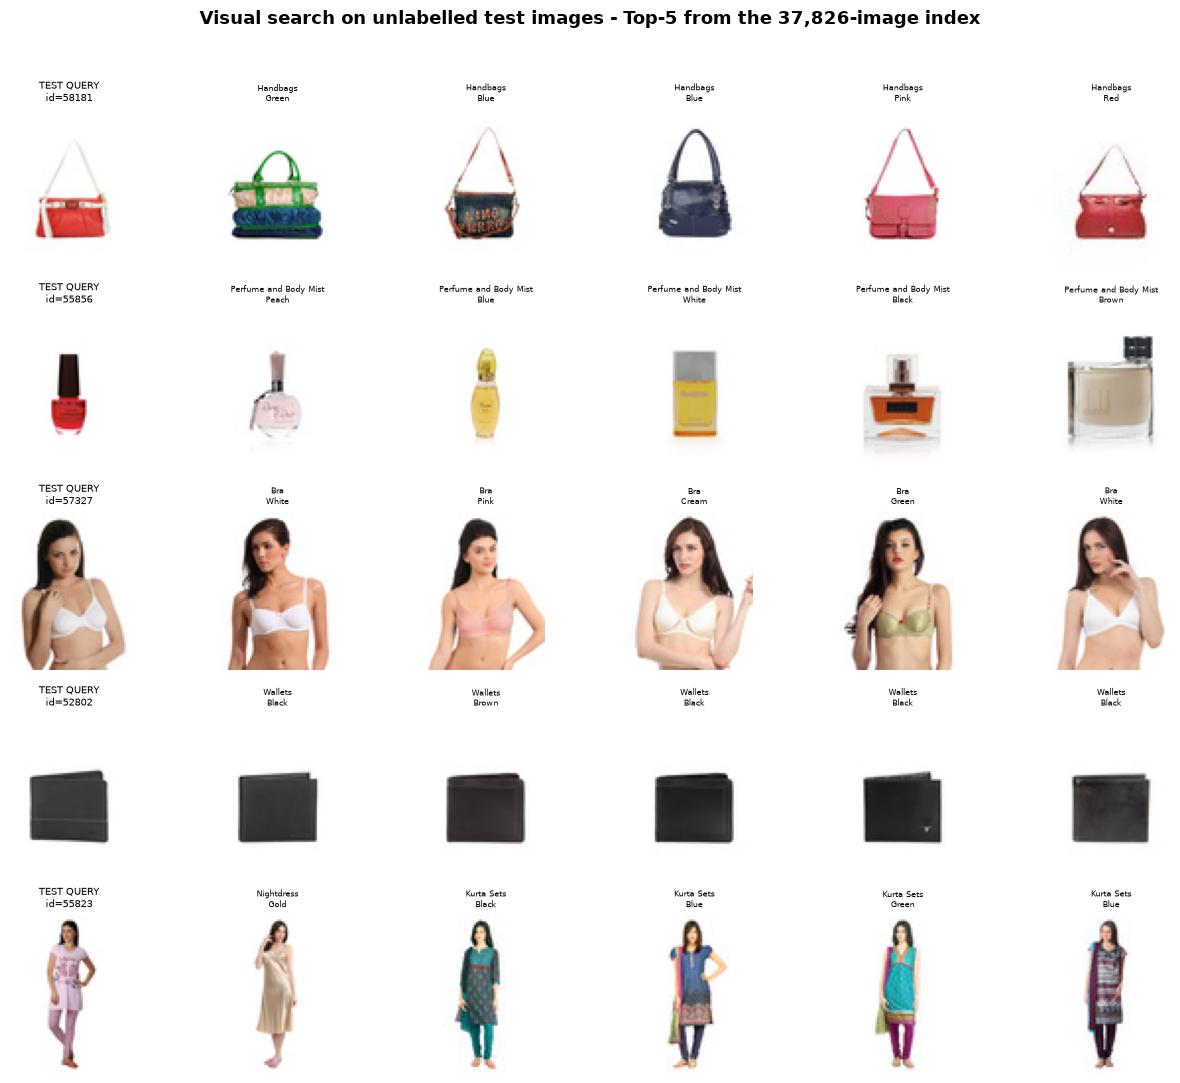

In [31]:
# Visual demo on genuinely unseen test images (no labels exist for these).
rng = np.random.default_rng(RANDOM_STATE)
picks = rng.choice(len(test_df), size=5, replace=False)
fig, axes = plt.subplots(5, 6, figsize=(13, 11))
for r, qi in enumerate(picks):
    axes[r, 0].imshow(test_cache[test_index[str(test_df.iloc[qi]['id'])]])
    axes[r, 0].set_title(f"TEST QUERY\nid={test_df.iloc[qi]['id']}", fontsize=7); axes[r, 0].axis('off')
    for c in range(5):
        g = deploy_df.iloc[test_topk[qi, c]]
        ax = axes[r, c + 1]
        ax.imshow(train_cache[train_index[str(g['id'])]])
        ax.set_title(f"{g['articleType_grouped']}\n{g['baseColour']}", fontsize=6)
        ax.axis('off')
fig.suptitle(f'Visual search on unlabelled test images - Top-5 from the {len(deploy_df):,}-image index',
             fontweight='bold', fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

## Final summary

Rank the 28,371 gallery images by visual similarity to a query and return the Top-K. There is no
label to predict, so the model outputs a 128-dimensional embedding and similarity is distance in that
space. Relevance is a metadata proxy, simple (`articleType_grouped`) and strict
(`articleType_grouped` and `baseColour`), against a random-ranker floor of 0.0912 and 0.0117.

| # | Approach | mAP@10 | What it tests |
|---|---|---|---|
| A | Raw downscaled pixels | 0.5707 | the no-learning floor |
| B | Colour histogram (512 bins) | 0.2080 | colour only, no shape |
| C | Classification CNN (Task 1's winner, head removed) | 0.7890 | what free transfer buys |
| D | Convolutional autoencoder | 0.6500 | is category supervision necessary? |
| E | Metric learning, batch-hard triplet | 0.7960 | optimising distance directly |
| F | E + ArcFace angular margin (rung 5) | 0.8213 | can both losses share one sphere? |
| G | E + supervised colour block (rung 3b) | 0.7491 | buying colour fidelity, and its cost |
| H | E + ArcFace + colour block (rung 6) | 0.8132 | combining the two that worked |

C and E differ only in the loss, and their gap came out at 0.0070 with overlapping intervals, which
is a tie. F, G and H exist because of it. A nine-rung ladder at a fixed 50-epoch budget asked which
single change moves the metric: GeM pooling bought nothing, auxiliary metadata heads measurably hurt,
colour cross-entropy at weight 1.00 collapsed, and ArcFace worked.

**F ships**: metric learning with an ArcFace angular margin, 128-d, mAP@10 0.8213 (CI 0.815-0.828),
clearing C's 0.7890 (0.782-0.796) with no overlap. Strict relevance was disqualified as a tiebreak
because H is trained on the label it scores, and independent attributes could not separate F from H
either, so F ships on cost to serve at half H's index size.

Re-scored against attributes never trained on, `subCategory` shows real transfer (0.9557 against
0.3659) and `gender` clears chance (0.8061 against 0.5455). No pretrained backbones were used. Task 4
fills no column of `styles_prediction.csv`; its deliverables are the model in
`outputs/task4_models/`, the deployment index, and the test-set retrieval demo.

## Reference:

Deng, J., Guo, J., Xue, N., & Zafeiriou, S. (2019). ArcFace: Additive angular margin loss for deep face recognition. In Proceedings of the 2019 IEEE/CVF Conference on Computer Vision and Pattern Recognition (CVPR) (pp. 4690-4699). IEEE.

He, K., Zhang, X., Ren, S., & Sun, J. (2016). Deep residual learning for image recognition. In Proceedings of the 2016 IEEE Conference on Computer Vision and Pattern Recognition (CVPR) (pp. 770-778). IEEE.